In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [9]:
data1= pd.read_csv('eggplant.csv')

In [10]:
data1

,Genotypes,Abbreviate form,DFF,FD,FL,FW,NDVI,PH,SLA,SPAD,TF,YPP,Gid
0,AC‐285,G1,109.07,61.34,6.13,9.93,0.51,108.82,132.40,46.75,15.21,7.83,1
1,BARI‐1,G2,99.32,40.97,4.10,8.30,0.48,89.82,121.08,45.59,21.96,11.13,2
2,BARI‐10,G3,95.32,38.47,3.85,9.50,0.60,103.82,119.16,62.32,14.96,5.72,3
3,BARI‐4,G4,98.32,44.96,4.50,8.00,0.58,93.82,159.86,63.09,29.96,14.54,4
4,BARI‐5,G5,93.82,57.79,5.78,8.20,0.56,94.07,111.21,39.09,13.71,7.67,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,SU‐234,G126,97.07,61.56,6.16,5.99,0.53,109.32,178.61,52.17,12.96,6.89,126
126,SU‐235,G127,97.07,40.50,4.05,4.87,0.58,114.32,132.18,44.45,12.96,7.73,127
127,SU‐38,G128,109.82,62.47,6.25,8.98,0.57,104.57,107.35,38.55,12.21,7.04,128
128,SU‐39,G129,91.82,70.50,7.05,7.46,0.58,100.57,86.12,47.21,18.21,9.22,129


In [11]:
data = data1.drop(columns=['Genotypes','Abbreviate form','Gid'])

In [12]:
data

,DFF,FD,FL,FW,NDVI,PH,SLA,SPAD,TF,YPP
0,109.07,61.34,6.13,9.93,0.51,108.82,132.40,46.75,15.21,7.83
1,99.32,40.97,4.10,8.30,0.48,89.82,121.08,45.59,21.96,11.13
2,95.32,38.47,3.85,9.50,0.60,103.82,119.16,62.32,14.96,5.72
3,98.32,44.96,4.50,8.00,0.58,93.82,159.86,63.09,29.96,14.54
4,93.82,57.79,5.78,8.20,0.56,94.07,111.21,39.09,13.71,7.67
...,...,...,...,...,...,...,...,...,...,...
125,97.07,61.56,6.16,5.99,0.53,109.32,178.61,52.17,12.96,6.89
126,97.07,40.50,4.05,4.87,0.58,114.32,132.18,44.45,12.96,7.73
127,109.82,62.47,6.25,8.98,0.57,104.57,107.35,38.55,12.21,7.04
128,91.82,70.50,7.05,7.46,0.58,100.57,86.12,47.21,18.21,9.22


In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

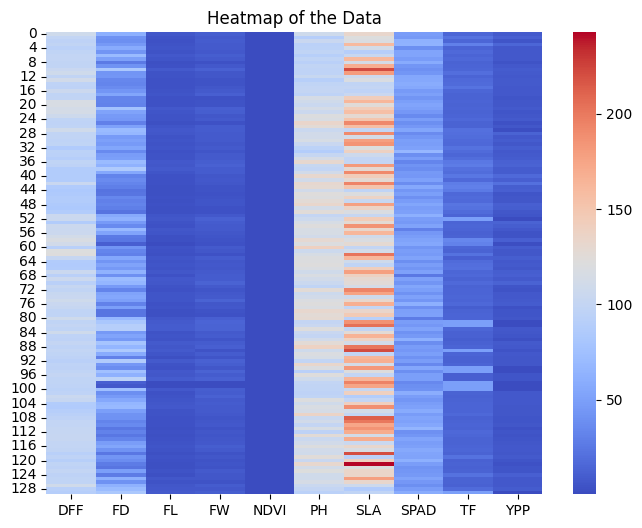

In [14]:
# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(data, cmap='coolwarm', cbar=True)

# Show the plot
plt.title("Heatmap of the Data")
plt.show()

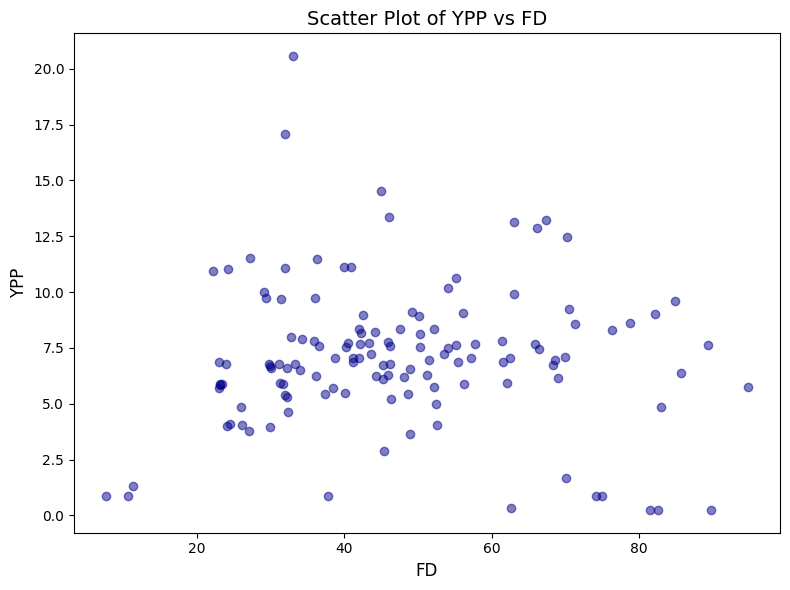

In [15]:
plt.figure(figsize=(8, 6))

# Plot 'YPP' against 'FD'
plt.scatter(data1['FD'], data1['YPP'], color='darkblue', alpha=0.5)

# Add labels and title
plt.title('Scatter Plot of YPP vs FD', fontsize=14)
plt.xlabel('FD', fontsize=12)
plt.ylabel('YPP', fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()

In [16]:
X = data.drop(columns=['YPP', 'DFF', 'FD', 'SLA', 'SPAD', 'NDVI', 'FL'])
y = data['YPP']

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
from sklearn.preprocessing import StandardScaler

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##XGB

In [21]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error
from sklearn.preprocessing import StandardScaler
import numpy as np

In [22]:
# Initialize and train the XGBoost Regressor as regression model2
regression2 = XGBRegressor(random_state=42)
regression2.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = regression2.predict(X_test_scaled)

# Calculate performance metrics
mse2 = mean_squared_error(y_test, y_pred)
mae2 = mean_absolute_error(y_test, y_pred)
medae2 = median_absolute_error(y_test, y_pred)
r2_2 = r2_score(y_test, y_pred)


In [23]:
# Display metrics
print("XGBoost Regressor (regressor2) Results:")
print(f"Mean Squared Error (MSE): {mse2:.2f}")
print(f"Mean Absolute Error (MAE): {mae2:.2f}")
print(f"Median Absolute Error (MedAE): {medae2:.2f}")
print(f"R-squared (R2): {r2_2 * 100:.2f}%")

XGBoost Regressor (regressor2) Results:
Mean Squared Error (MSE): 7.08
Mean Absolute Error (MAE): 1.63
Median Absolute Error (MedAE): 1.06
R-squared (R2): 38.44%


##LGBM

In [24]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np

d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\dask\dataframe\__init__.py:49: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [25]:
# Initialize and train the LightGBM Regressor as regression model3
regression3 = LGBMRegressor(random_state=42)
regression3.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = regression3.predict(X_test_scaled)

# Calculate performance metrics
mse3 = mean_squared_error(y_test, y_pred)
mae3 = mean_absolute_error(y_test, y_pred)
medae3 = median_absolute_error(y_test, y_pred)
r2_3 = r2_score(y_test, y_pred)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000064 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 90
[LightGBM] [Info] Number of data points in the train set: 104, number of used features: 3
[LightGBM] [Info] Start training from score 7.306538
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [26]:
# Display metrics
print("LightGBM Regressor (regressor3) Results:")
print(f"Mean Squared Error (MSE): {mse3:.2f}")
print(f"Mean Absolute Error (MAE): {mae3:.2f}")
print(f"Median Absolute Error (MedAE): {medae3:.2f}")
print(f"R-squared (R2): {r2_3 * 100:.2f}%")

LightGBM Regressor (regressor3) Results:
Mean Squared Error (MSE): 8.82
Mean Absolute Error (MAE): 2.21
Median Absolute Error (MedAE): 1.43
R-squared (R2): 23.37%


##Catboost

In [27]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np

In [28]:
# Initialize and train the CatBoost Regressor as regression4
regression4 = CatBoostRegressor(verbose=0, random_state=42)
regression4.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = regression4.predict(X_test_scaled)

# Calculate performance metrics
mse4 = mean_squared_error(y_test, y_pred)
mae4 = mean_absolute_error(y_test, y_pred)
medae4 = median_absolute_error(y_test, y_pred)
r2_4 = r2_score(y_test, y_pred)

In [29]:
# Display metrics
print("CatBoost Regressor (regression4) Results:")
print(f"Mean Squared Error (MSE): {mse4:.2f}")
print(f"Mean Absolute Error (MAE): {mae4:.2f}")
print(f"Median Absolute Error (MedAE): {medae4:.2f}")
print(f"R-squared (R2): {r2_4 * 100:.2f}%")

CatBoost Regressor (regression4) Results:
Mean Squared Error (MSE): 5.41
Mean Absolute Error (MAE): 1.40
Median Absolute Error (MedAE): 0.82
R-squared (R2): 53.02%


##Kernel Ridge Regression

In [30]:
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np

In [31]:
# Initialize and train the Kernel Ridge Regressor as regression5
regression5 = KernelRidge(kernel='rbf', alpha=1.0)
regression5.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = regression5.predict(X_test_scaled)

# Calculate performance metrics
mse5 = mean_squared_error(y_test, y_pred)
mae5 = mean_absolute_error(y_test, y_pred)
medae5 = median_absolute_error(y_test, y_pred)
r2_5 = r2_score(y_test, y_pred)

In [32]:
# Display metrics
print("Kernel Ridge Regression (regression5) Results:")
print(f"Mean Squared Error (MSE): {mse5:.2f}")
print(f"Mean Absolute Error (MAE): {mae5:.2f}")
print(f"Median Absolute Error (MedAE): {medae5:.2f}")
print(f"R-squared (R2): {r2_5 * 100:.2f}%")

Kernel Ridge Regression (regression5) Results:
Mean Squared Error (MSE): 6.37
Mean Absolute Error (MAE): 1.58
Median Absolute Error (MedAE): 1.07
R-squared (R2): 44.61%


##Gradient Boosting Regression

In [33]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np

In [34]:
# Initialize and train the Gradient Boosting Regressor as regression7
regression7 = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
regression7.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = regression7.predict(X_test_scaled)

# Calculate performance metrics
mse7 = mean_squared_error(y_test, y_pred)
mae7 = mean_absolute_error(y_test, y_pred)
medae7 = median_absolute_error(y_test, y_pred)
r2_7 = r2_score(y_test, y_pred)

In [35]:
# Display metrics
print("Gradient Boosting Regression (regression7) Results:")
print(f"Mean Squared Error (MSE): {mse7:.2f}")
print(f"Mean Absolute Error (MAE): {mae7:.2f}")
print(f"Median Absolute Error (MedAE): {medae7:.2f}")
print(f"R-squared (R2): {r2_7 * 100:.2f}%")

Gradient Boosting Regression (regression7) Results:
Mean Squared Error (MSE): 5.04
Mean Absolute Error (MAE): 1.42
Median Absolute Error (MedAE): 0.81
R-squared (R2): 56.16%


##Random Forest

In [36]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np

In [37]:
# Initialize and train the Random Forest Regressor as regression8
regression8 = RandomForestRegressor(n_estimators=100, random_state=42)
regression8.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = regression8.predict(X_test_scaled)

# Calculate performance metrics
mse8 = mean_squared_error(y_test, y_pred)
mae8 = mean_absolute_error(y_test, y_pred)
medae8 = median_absolute_error(y_test, y_pred)
r2_8 = r2_score(y_test, y_pred)

In [38]:
# Display metrics
print("Random Forest Regression (regression8) Results:")
print(f"Mean Squared Error (MSE): {mse8:.2f}")
print(f"Mean Absolute Error (MAE): {mae8:.2f}")
print(f"Median Absolute Error (MedAE): {medae8:.2f}")
print(f"R-squared (R2): {r2_8 * 100:.2f}%")

Random Forest Regression (regression8) Results:
Mean Squared Error (MSE): 5.37
Mean Absolute Error (MAE): 1.46
Median Absolute Error (MedAE): 1.20
R-squared (R2): 53.30%


##Support Vector Regression (SVR)

In [39]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [40]:
# Initialize and train the Support Vector Regressor (SVR) as regression9
regression9 = SVR(kernel='rbf', C=1e3, gamma=0.1)
regression9.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = regression9.predict(X_test_scaled)

# Calculate performance metrics
mse9 = mean_squared_error(y_test, y_pred)
mae9 = mean_absolute_error(y_test, y_pred)
medae9 = median_absolute_error(y_test, y_pred)
r2_9 = r2_score(y_test, y_pred)

In [41]:
# Display metrics
print("Support Vector Regression (SVR) Results:")
print(f"Mean Squared Error (MSE): {mse9:.2f}")
print(f"Mean Absolute Error (MAE): {mae9:.2f}")
print(f"Median Absolute Error (MedAE): {medae9:.2f}")
print(f"R-squared (R2): {r2_9 * 100:.2f}%")

Support Vector Regression (SVR) Results:
Mean Squared Error (MSE): 5.57
Mean Absolute Error (MAE): 1.62
Median Absolute Error (MedAE): 0.94
R-squared (R2): 51.56%


##K-Nearest Neighbors Regression (KNN)

In [42]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [43]:
# Initialize and train the K-Nearest Neighbors Regressor (KNN) as regression10
regression10 = KNeighborsRegressor(n_neighbors=2)
regression10.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = regression10.predict(X_test_scaled)

# Calculate performance metrics
mse10 = mean_squared_error(y_test, y_pred)
mae10 = mean_absolute_error(y_test, y_pred)
medae10 = median_absolute_error(y_test, y_pred)
r2_10 = r2_score(y_test, y_pred)

In [44]:
# Display metrics
print("K-Nearest Neighbors Regression (KNN) Results:")
print(f"Mean Squared Error (MSE): {mse10:.2f}")
print(f"Mean Absolute Error (MAE): {mae10:.2f}")
print(f"Median Absolute Error (MedAE): {medae10:.2f}")
print(f"R-squared (R2): {r2_10 * 100:.2f}%")

K-Nearest Neighbors Regression (KNN) Results:
Mean Squared Error (MSE): 6.05
Mean Absolute Error (MAE): 1.72
Median Absolute Error (MedAE): 1.21
R-squared (R2): 47.46%


##Decision Tree Regression

In [45]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [46]:
# Initialize and train the Decision Tree Regressor (DecisionTreeRegressor) as regression11
regression11 = DecisionTreeRegressor(random_state=42)
regression11.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = regression11.predict(X_test_scaled)

# Calculate performance metrics
mse11 = mean_squared_error(y_test, y_pred)
mae11 = mean_absolute_error(y_test, y_pred)
medae11 = median_absolute_error(y_test, y_pred)
r2_11 = r2_score(y_test, y_pred)


In [47]:
# Display metrics
print("Decision Tree Regression Results:")
print(f"Mean Squared Error (MSE): {mse11:.2f}")
print(f"Mean Absolute Error (MAE): {mae11:.2f}")
print(f"Median Absolute Error (MedAE): {medae11:.2f}")
print(f"R-squared (R2): {r2_11 * 100:.2f}%")

Decision Tree Regression Results:
Mean Squared Error (MSE): 6.21
Mean Absolute Error (MAE): 1.69
Median Absolute Error (MedAE): 1.28
R-squared (R2): 46.05%


##HistGradientBoostingRegressor

In [48]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [49]:
# Initialize and train the HistGradientBoostingRegressor (HistGradientBoostingRegressor) as regression12
regression12 = HistGradientBoostingRegressor(max_iter=100, random_state=42)
regression12.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = regression12.predict(X_test_scaled)

# Calculate performance metrics
mse12 = mean_squared_error(y_test, y_pred)
mae12 = mean_absolute_error(y_test, y_pred)
medae12 = median_absolute_error(y_test, y_pred)
r2_12 = r2_score(y_test, y_pred)

In [50]:
# Display metrics
print("HistGradientBoostingRegressor Results:")
print(f"Mean Squared Error (MSE): {mse12:.2f}")
print(f"Mean Absolute Error (MAE): {mae12:.2f}")
print(f"Median Absolute Error (MedAE): {medae12:.2f}")
print(f"R-squared (R2): {r2_12 * 100:.2f}%")

HistGradientBoostingRegressor Results:
Mean Squared Error (MSE): 8.24
Mean Absolute Error (MAE): 2.14
Median Absolute Error (MedAE): 1.53
R-squared (R2): 28.38%


##Multi-layer Perceptron (MLP)

In [51]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [52]:
# Initialize and train the Multi-layer Perceptron Regressor (MLP) as regression15
regression15 = MLPRegressor(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)

# Fit the model
regression15.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = regression15.predict(X_test_scaled)

# Calculate performance metrics
mse15 = mean_squared_error(y_test, y_pred)
mae15 = mean_absolute_error(y_test, y_pred)
medae15 = median_absolute_error(y_test, y_pred)
r2_15 = r2_score(y_test, y_pred)

d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [53]:
# Display metrics
print("Multi-layer Perceptron (MLP) Regression Results:")
print(f"Mean Squared Error (MSE): {mse15:.2f}")
print(f"Mean Absolute Error (MAE): {mae15:.2f}")
print(f"Median Absolute Error (MedAE): {medae15:.2f}")
print(f"R-squared (R2): {r2_15 * 100:.2f}%")

Multi-layer Perceptron (MLP) Regression Results:
Mean Squared Error (MSE): 4.80
Mean Absolute Error (MAE): 1.46
Median Absolute Error (MedAE): 1.06
R-squared (R2): 58.25%


In [54]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [55]:
# Store metrics for each model
models = [
    "XGBoost", "LightGBM", "CatBoost", "Kernel Ridge",
    "Gradient Boosting", "Random Forest", "SVR", "KNN",
    "Decision Tree", "HistGradientBoosting", "MLP"
]

# Create a list of metrics for each model
mse_values = [mse2, mse3, mse4, mse5, mse7, mse8, mse9, mse10, mse11, mse12, mse15]
mae_values = [mae2, mae3, mae4, mae5, mae7, mae8, mae9, mae10, mae11, mae12, mae15]
medae_values = [medae2, medae3, medae4, medae5, medae7, medae8, medae9, medae10, medae11, medae12, medae15]
r2_values = [r2_2, r2_3, r2_4, r2_5, r2_7, r2_8, r2_9, r2_10, r2_11, r2_12, r2_15]

# Create a DataFrame for better visualization
df_metrics = pd.DataFrame({
    "Model": models,
    "MSE": mse_values,
    "MAE": mae_values,
    "MedAE": medae_values,
    "R2": r2_values
})


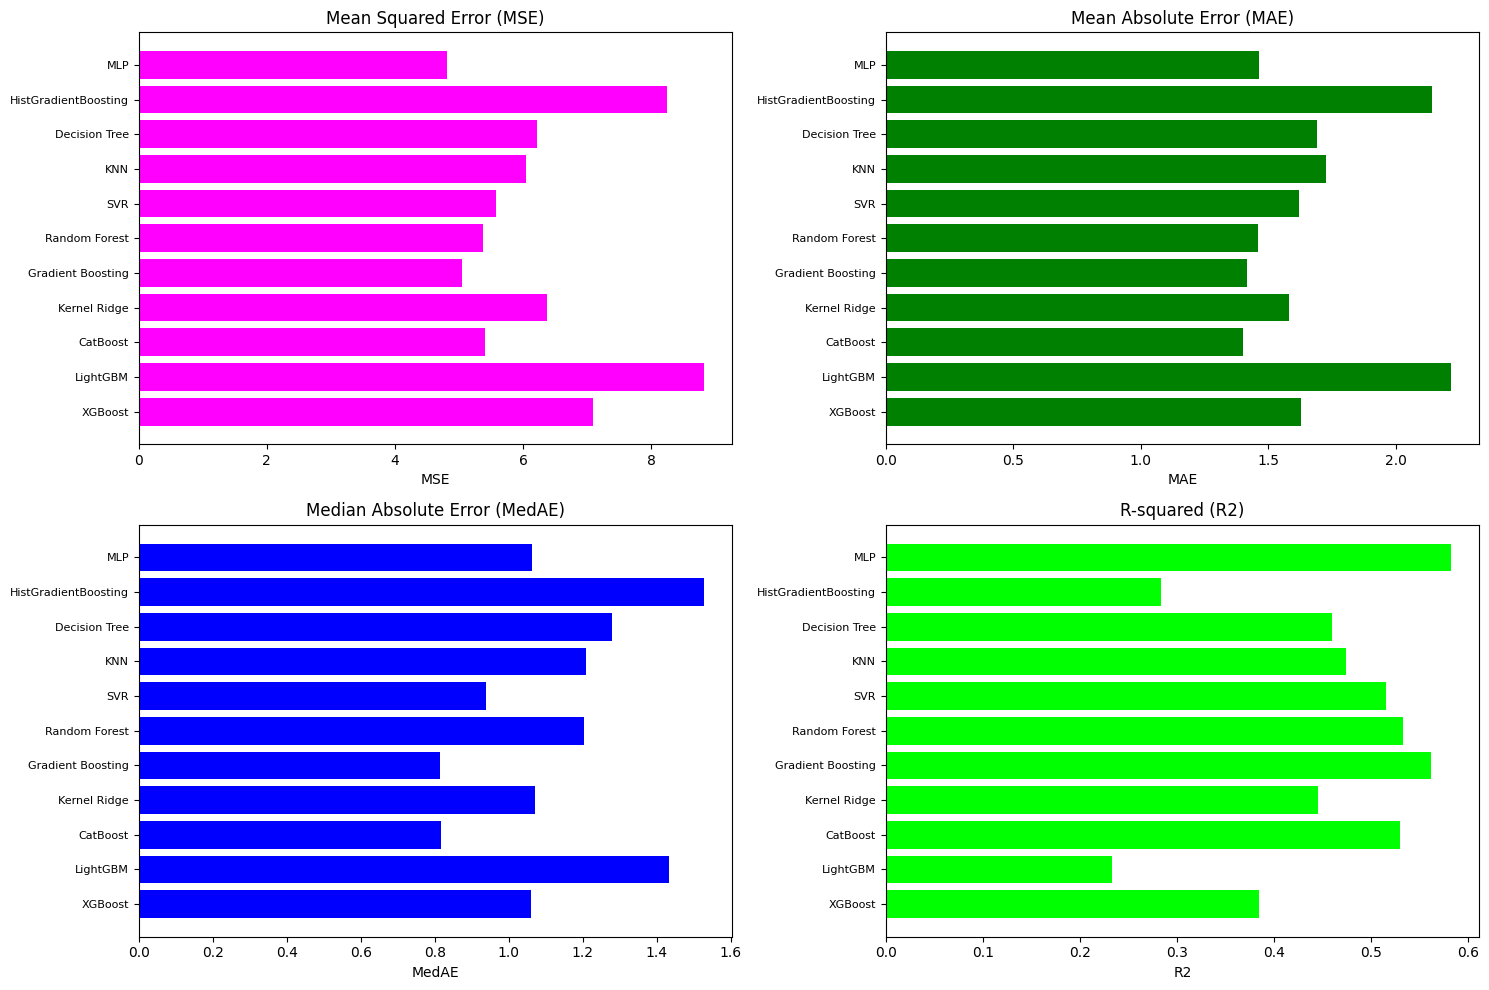

In [56]:
# Plot the metrics
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

# Bar chart for MSE with bright colors
ax[0, 0].barh(df_metrics["Model"], df_metrics["MSE"], color='magenta')
ax[0, 0].set_title("Mean Squared Error (MSE)")
ax[0, 0].set_xlabel("MSE")
ax[0, 0].tick_params(axis='y', labelsize=8)

# Bar chart for MAE with bright colors
ax[0, 1].barh(df_metrics["Model"], df_metrics["MAE"], color='green')
ax[0, 1].set_title("Mean Absolute Error (MAE)")
ax[0, 1].set_xlabel("MAE")
ax[0, 1].tick_params(axis='y', labelsize=8)

# Bar chart for RMSE with bright colors
ax[1, 0].barh(df_metrics["Model"], df_metrics["MedAE"], color='blue')
ax[1, 0].set_title("Median Absolute Error (MedAE)")
ax[1, 0].set_xlabel("MedAE")
ax[1, 0].tick_params(axis='y', labelsize=8)

# Bar chart for R-squared (R2) with bright colors
ax[1, 1].barh(df_metrics["Model"], df_metrics["R2"], color='lime')
ax[1, 1].set_title("R-squared (R2)")
ax[1, 1].set_xlabel("R2")
ax[1, 1].tick_params(axis='y', labelsize=8)

# Adjust layout
plt.tight_layout()
plt.show()

##Voting with 3 model

In [57]:
import itertools
from sklearn.ensemble import VotingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error
import matplotlib.pyplot as plt
import numpy as np

In [58]:
# List of all regression models (same as before)
models_dict = {
    "XGBoost": regression2,
    "LightGBM": regression3,
    "CatBoost": regression4,
    "Kernel Ridge": regression5,
    "Gradient Boosting": regression7,
    "Random Forest": regression8,
    "SVR": regression9,
    "KNN": regression10,
    "Decision Tree": regression11,
    "HistGradientBoosting": regression12,
    "MLP": regression15
}


In [59]:
# Initialize variables to track the best model combination
best_model = None
best_r2 = -float('inf')  # Initialize to a very low value to ensure any model can be better
best_results = {}

In [60]:
# Loop over all combinations of 3 models
for combo in itertools.combinations(models_dict.items(), 3):
    model_names, models = zip(*combo)

    try:
        # Create a Voting Regressor with the combination of 3 models
        voting_regressor = VotingRegressor(estimators=[(name, model) for name, model in zip(model_names, models)])

        # Train the Voting Regressor
        voting_regressor.fit(X_train_scaled, y_train)

        # Make predictions
        y_pred = voting_regressor.predict(X_test_scaled)

        # Evaluate the performance of this model
        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        medae = median_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        # Update best results if the current model is better
        if r2 >= best_r2:
            best_r2 = r2
            best_model = combo
            best_results = {
                'Combination': ', '.join(model_names),
                'MSE': mse,
                'MAE': mae,
                'MedAE': medae,
                'R2': r2
            }

    except Exception as e:
        print(f"Error with combination {model_names}: {e}")

Error with combination ('XGBoost', 'LightGBM', 'CatBoost'): 'super' object has no attribute '__sklearn_tags__'
Error with combination ('XGBoost', 'LightGBM', 'Kernel Ridge'): 'super' object has no attribute '__sklearn_tags__'
Error with combination ('XGBoost', 'LightGBM', 'Gradient Boosting'): 'super' object has no attribute '__sklearn_tags__'
Error with combination ('XGBoost', 'LightGBM', 'Random Forest'): 'super' object has no attribute '__sklearn_tags__'
Error with combination ('XGBoost', 'LightGBM', 'SVR'): 'super' object has no attribute '__sklearn_tags__'
Error with combination ('XGBoost', 'LightGBM', 'KNN'): 'super' object has no attribute '__sklearn_tags__'
Error with combination ('XGBoost', 'LightGBM', 'Decision Tree'): 'super' object has no attribute '__sklearn_tags__'
Error with combination ('XGBoost', 'LightGBM', 'HistGradientBoosting'): 'super' object has no attribute '__sklearn_tags__'
Error with combination ('XGBoost', 'LightGBM', 'MLP'): 'super' object has no attribute 

d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000028 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 90
[LightGBM] [Info] Number of data points in the train set: 104, number of used features: 3
[LightGBM] [Info] Start training from score 7.306538
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000019 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 90
[LightGBM] [Info] Number of data points in the train set: 104, number of used features: 3
[LightGBM] [Info] Start training from score 7.306538
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

...

d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000021 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 90
[LightGBM] [Info] Number of data points in the train set: 104, number of used features: 3
[LightGBM] [Info] Start training from score 7.306538
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000021 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 90
[LightGBM] [Info] Number of data points in the train set: 104, number of used features: 3
[LightGBM] [Info] Start training from score 7.306538
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site

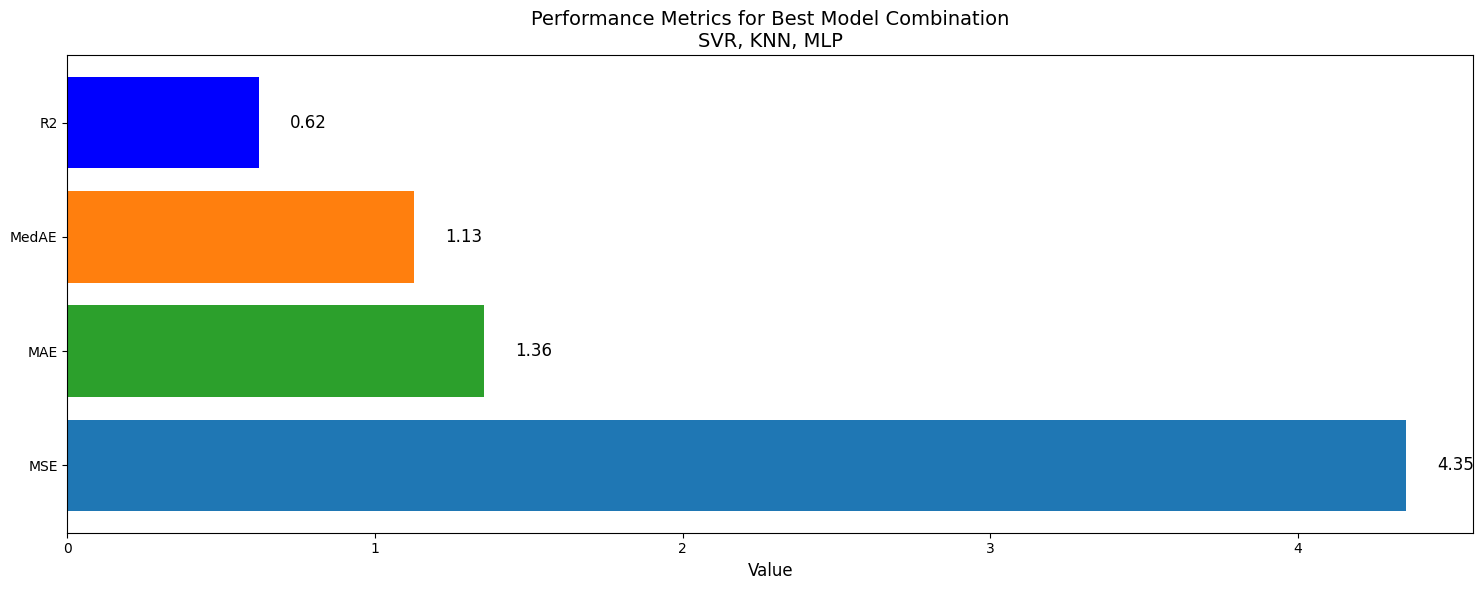

In [61]:
# If the best model was found
if best_model:
    # Prepare the data for the combined plot
    metrics = ['MSE', 'MAE', 'MedAE', 'R2']
    values = [best_results['MSE'], best_results['MAE'], best_results['MedAE'], best_results['R2']]
    colors = ['#1f77b4', '#2ca02c', '#ff7f0e', 'blue']

    # Plot all metrics in one horizontal bar plot
    plt.figure(figsize=(15, 6))

    # Plot the bars
    plt.barh(metrics, values, color=colors)

    # Add the values on top of each bar
    for i, v in enumerate(values):
        plt.text(v + 0.1, i, f'{v:.2f}', va='center', ha='left', fontsize=12)

    # Set the title and labels
    plt.title(f'Performance Metrics for Best Model Combination\n{best_results["Combination"]}', fontsize=14)
    plt.xlabel('Value', fontsize=12)

    # Show the plot
    plt.tight_layout()
    plt.show()

else:
    print("No model combination has R² greater than 50%.")

In [62]:
import optuna
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.neural_network import MLPRegressor

d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [63]:
# Define models and their parameters
models = {
    "XGBoost": XGBRegressor,
    "LightGBM": LGBMRegressor,
    "CatBoost": CatBoostRegressor,
    "Random Forest": RandomForestRegressor,
    "Gradient Boosting": GradientBoostingRegressor,
    "HistGradientBoosting": HistGradientBoostingRegressor,
    "Support Vector Regression (SVR)": SVR,
    "Decision Tree": DecisionTreeRegressor,
    "K-Nearest Neighbors": KNeighborsRegressor,
    "MLP Regressor": MLPRegressor,
    "Kernel Ridge Regression": KernelRidge,
}


In [64]:
# Optimization space for each model
def get_model_params(model_name, trial):
    if model_name == "XGBoost":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 50, 300),
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "gamma": trial.suggest_float("gamma", 0, 1),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        }
    elif model_name == "LightGBM":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 50, 300),
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 10, 100),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 30),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        }
    elif model_name == "CatBoost":
        return {
            "iterations": trial.suggest_int("iterations", 50, 300),
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
            "depth": trial.suggest_int("depth", 3, 10),
        }
    elif model_name in ["Random Forest", "Gradient Boosting"]:
        return {
            "n_estimators": trial.suggest_int("n_estimators", 50, 300),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
        }
    elif model_name == "HistGradientBoosting":
        return {
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
            "max_iter": trial.suggest_int("max_iter", 50, 300),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
        }
    elif model_name == "Support Vector Regression (SVR)":
        return {
            "C": trial.suggest_float("C", 1e-3, 10, log=True),
            "epsilon": trial.suggest_float("epsilon", 0.01, 1.0),
            "kernel": trial.suggest_categorical("kernel", ["linear", "rbf", "poly"]),
        }
    elif model_name == "Decision Tree":
        return {
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
        }
    elif model_name == "K-Nearest Neighbors":
        return {
            "n_neighbors": trial.suggest_int("n_neighbors", 3, 15),
            "weights": trial.suggest_categorical("weights", ["uniform", "distance"]),
            "p": trial.suggest_int("p", 1, 2),
        }
    elif model_name == "MLP Regressor":
        return {
            "hidden_layer_sizes": trial.suggest_int("hidden_layer_sizes", 50, 200),
            "learning_rate_init": trial.suggest_float("learning_rate_init", 1e-3, 0.1, log=True),
            "alpha": trial.suggest_float("alpha", 1e-3, 10.0, log=True),
            "max_iter": trial.suggest_int("max_iter", 200, 500),
        }
    elif model_name == "Kernel Ridge Regression":
        return {
            "alpha": trial.suggest_float("alpha", 1e-3, 10.0, log=True),
            "kernel": trial.suggest_categorical("kernel", ["linear", "rbf", "poly"]),
        }


In [65]:
# Optimization function
def objective(trial, model_name, X_train, X_test, y_train, y_test):
    model_class = models[model_name]
    params = get_model_params(model_name, trial)
    model = model_class(**params)
    if model_name == "CatBoost":
        model.set_params(silent=True)  # Suppress output for CatBoost

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    return mse

In [66]:
# Tune all models
best_params = {}
for model_name in models.keys():
    print(f"Tuning {model_name}...")
    study = optuna.create_study(direction="minimize")
    study.optimize(lambda trial: objective(trial, model_name, X_train_scaled, X_test_scaled, y_train, y_test), n_trials=50)
    best_params[model_name] = study.best_params
    print(f"Best parameters for {model_name}: {study.best_params}")
    print(f"Best MSE for {model_name}: {study.best_value:.4f}\n")

[I 2025-01-25 18:18:19,371] A new study created in memory with name: no-name-39a800a5-abfa-4d5a-991d-932d1e7bcf45
[I 2025-01-25 18:18:19,414] Trial 0 finished with value: 5.913428810116462 and parameters: {'n_estimators': 113, 'learning_rate': 0.020728351324166793, 'max_depth': 5, 'subsample': 0.6282173955369015, 'colsample_bytree': 0.7631872405058578, 'gamma': 0.31306759540441387, 'min_child_weight': 2}. Best is trial 0 with value: 5.913428810116462.
[I 2025-01-25 18:18:19,456] Trial 1 finished with value: 5.620301445605383 and parameters: {'n_estimators': 178, 'learning_rate': 0.03298803526470948, 'max_depth': 3, 'subsample': 0.6089023284437985, 'colsample_bytree': 0.7502632302655501, 'gamma': 0.9018976468842487, 'min_child_weight': 2}. Best is trial 1 with value: 5.620301445605383.
[I 2025-01-25 18:18:19,486] Trial 2 finished with value: 10.597609761798138 and parameters: {'n_estimators': 110, 'learning_rate': 0.03541091265768006, 'max_depth': 5, 'subsample': 0.5130767436971022, 'co

Tuning XGBoost...


[I 2025-01-25 18:18:19,559] Trial 4 finished with value: 6.3456963132701 and parameters: {'n_estimators': 116, 'learning_rate': 0.0916486851897607, 'max_depth': 5, 'subsample': 0.6394145967926543, 'colsample_bytree': 0.8062472024942815, 'gamma': 0.5056335234048385, 'min_child_weight': 6}. Best is trial 1 with value: 5.620301445605383.
[I 2025-01-25 18:18:19,660] Trial 5 finished with value: 8.676952288040745 and parameters: {'n_estimators': 271, 'learning_rate': 0.0019044818949337588, 'max_depth': 8, 'subsample': 0.9024390393912931, 'colsample_bytree': 0.8940083303778683, 'gamma': 0.913282201521626, 'min_child_weight': 4}. Best is trial 1 with value: 5.620301445605383.
[I 2025-01-25 18:18:19,689] Trial 6 finished with value: 9.478427225570886 and parameters: {'n_estimators': 77, 'learning_rate': 0.006428304467666202, 'max_depth': 6, 'subsample': 0.593794745673292, 'colsample_bytree': 0.6918690578747291, 'gamma': 0.06269742810533918, 'min_child_weight': 2}. Best is trial 1 with value: 5

Best parameters for XGBoost: {'n_estimators': 222, 'learning_rate': 0.018194677304377203, 'max_depth': 3, 'subsample': 0.7760789094123354, 'colsample_bytree': 0.6787281650964478, 'gamma': 0.0010469640569700407, 'min_child_weight': 4}
Best MSE for XGBoost: 4.7413

Tuning LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000024 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 90
[LightGBM] [Info] Number of data points in the train set: 104, number of used features: 3
[LightGBM] [Info] Start training from score 7.306538
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Ligh

d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
[I 2025-01-25 18:18:23,348] Trial 10 finished with value: 5.56287589990707 and parameters: {'n_estimators': 262, 'learning_rate': 0.08191927932151265, 'num_leaves': 42, 'min_child_samples': 5, 'subsample': 0.9835354725006157}. Best is trial 9 with value: 5.552228237367482.
d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\utils\deprecation.py:151:

...

Best parameters for K-Nearest Neighbors: {'n_neighbors': 6, 'weights': 'distance', 'p': 1}
Best MSE for K-Nearest Neighbors: 4.7246

Tuning MLP Regressor...


d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (377) reached and the optimization hasn't converged yet.
  warnings.warn(
[I 2025-01-25 18:18:59,087] Trial 0 finished with value: 5.669953577707793 and parameters: {'hidden_layer_sizes': 160, 'learning_rate_init': 0.01569662281675974, 'alpha': 0.014956897868388712, 'max_iter': 377}. Best is trial 0 with value: 5.669953577707793.
d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (320) reached and the optimization hasn't converged yet.
  warnings.warn(
[I 2025-01-25 18:18:59,238] Trial 1 finished with value: 7.181314265549114 and parameters: {'hidden_layer_sizes': 103, 'learning_rate_init': 0.0012156377179606307, 'alpha': 0.0027182358037269863, 'max_iter': 320}. Best is trial 0 with value: 5.669953

Best parameters for MLP Regressor: {'hidden_layer_sizes': 97, 'learning_rate_init': 0.08497870495468804, 'alpha': 0.10358937555600388, 'max_iter': 369}
Best MSE for MLP Regressor: 3.9056

Tuning Kernel Ridge Regression...


[I 2025-01-25 18:19:06,153] Trial 36 finished with value: 4.995659282559301 and parameters: {'alpha': 6.7182827883508045, 'kernel': 'poly'}. Best is trial 26 with value: 4.779570652854297.
[I 2025-01-25 18:19:06,158] Trial 37 finished with value: 48.87379832044894 and parameters: {'alpha': 2.7550709467631256, 'kernel': 'linear'}. Best is trial 26 with value: 4.779570652854297.
[I 2025-01-25 18:19:06,165] Trial 38 finished with value: 5.488917163670203 and parameters: {'alpha': 0.29464554698085055, 'kernel': 'poly'}. Best is trial 26 with value: 4.779570652854297.
[I 2025-01-25 18:19:06,171] Trial 39 finished with value: 48.83042668250596 and parameters: {'alpha': 0.9408239543796643, 'kernel': 'linear'}. Best is trial 26 with value: 4.779570652854297.
[I 2025-01-25 18:19:06,178] Trial 40 finished with value: 4.9404917060971725 and parameters: {'alpha': 6.041530977624519, 'kernel': 'poly'}. Best is trial 26 with value: 4.779570652854297.
[I 2025-01-25 18:19:06,185] Trial 41 finished with

Best parameters for Kernel Ridge Regression: {'alpha': 0.004184134565625071, 'kernel': 'rbf'}
Best MSE for Kernel Ridge Regression: 4.0984



In [67]:
# Save best parameters for all models
print("Best parameters for all models:")
for model, params in best_params.items():
    print(f"{model}: {params}")

Best parameters for all models:
XGBoost: {'n_estimators': 222, 'learning_rate': 0.018194677304377203, 'max_depth': 3, 'subsample': 0.7760789094123354, 'colsample_bytree': 0.6787281650964478, 'gamma': 0.0010469640569700407, 'min_child_weight': 4}
LightGBM: {'n_estimators': 271, 'learning_rate': 0.059003921694335576, 'num_leaves': 34, 'min_child_samples': 7, 'subsample': 0.9584984854446479}
CatBoost: {'iterations': 189, 'learning_rate': 0.04195225576553437, 'depth': 5}
Random Forest: {'n_estimators': 210, 'max_depth': 3, 'min_samples_split': 3, 'min_samples_leaf': 1}
Gradient Boosting: {'n_estimators': 75, 'max_depth': 4, 'min_samples_split': 6, 'min_samples_leaf': 3}
HistGradientBoosting: {'learning_rate': 0.05263909684512415, 'max_iter': 82, 'max_depth': 3, 'min_samples_leaf': 3}
Support Vector Regression (SVR): {'C': 1.8093312823113559, 'epsilon': 0.27582037046206276, 'kernel': 'poly'}
Decision Tree: {'max_depth': 4, 'min_samples_split': 5, 'min_samples_leaf': 4}
K-Nearest Neighbors: 

In [68]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Lasso, Ridge
import numpy as np

In [69]:
# Initialize a dictionary to store all the models using the best parameters
models = {}

for model_name, params in best_params.items():
    # Initialize each model based on the name and best parameters
    if model_name == 'XGBoost':
        models[model_name] = XGBRegressor(**params)
    elif model_name == 'Support Vector Regression (SVR)':
        models[model_name] = SVR(**params)
    elif model_name == 'K-Nearest Neighbors':
        models[model_name] = KNeighborsRegressor(**params)
    elif model_name == 'Decision Tree':
        models[model_name] = DecisionTreeRegressor(**params)
    elif model_name == 'Random Forest':
        models[model_name] = RandomForestRegressor(**params)
    elif model_name == 'Gradient Boosting':
        models[model_name] = GradientBoostingRegressor(**params)
    elif model_name == 'HistGradientBoosting':
        models[model_name] = HistGradientBoostingRegressor(**params)
    elif model_name == 'CatBoost':
        models[model_name] = CatBoostRegressor(**params)
    elif model_name == 'LightGBM':
        models[model_name] = LGBMRegressor(**params)
    elif model_name == 'Kernel Ridge Regression':
        models[model_name] = KernelRidge(**params)
    elif model_name == 'MLP Regressor':
        models[model_name] = MLPRegressor(**params)
# Print the models to check if all were initialized correctly
print(f"Initialized models: {models.keys()}")

Initialized models: dict_keys(['XGBoost', 'LightGBM', 'CatBoost', 'Random Forest', 'Gradient Boosting', 'HistGradientBoosting', 'Support Vector Regression (SVR)', 'Decision Tree', 'K-Nearest Neighbors', 'MLP Regressor', 'Kernel Ridge Regression'])


In [70]:
# Store the results
results = {}

In [71]:
# Train each model and evaluate performance
for model_name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train)

    # Make predictions
    y_pred = model.predict(X_test_scaled)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    medae = median_absolute_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Store the results
    results[model_name] = {
        'MSE': mse,
        'MedAE': medae,
        'MAE': mae,
        'R2': r2
    }

d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000025 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 90
[LightGBM] [Info] Number of data points in the train set: 104, number of used features: 3
[LightGBM] [Info] Start training from score 7.306538
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

In [72]:
for model_name, metrics in results.items():
    print(f"{model_name} - MSE: {metrics['MSE']:.2f}, MedAE: {metrics['MedAE']:.2f}, MAE: {metrics['MAE']:.2f}, R²: {metrics['R2']*100:.2f}%")

XGBoost - MSE: 4.74, MedAE: 1.04, MAE: 1.39, R²: 58.80%
LightGBM - MSE: 4.77, MedAE: 0.99, MAE: 1.41, R²: 58.53%
CatBoost - MSE: 4.38, MedAE: 0.94, MAE: 1.34, R²: 61.92%
Random Forest - MSE: 4.70, MedAE: 0.78, MAE: 1.32, R²: 59.13%
Gradient Boosting - MSE: 4.12, MedAE: 0.65, MAE: 1.29, R²: 64.22%
HistGradientBoosting - MSE: 4.08, MedAE: 0.77, MAE: 1.23, R²: 64.59%
Support Vector Regression (SVR) - MSE: 5.82, MedAE: 1.23, MAE: 1.73, R²: 49.47%
Decision Tree - MSE: 4.18, MedAE: 1.26, MAE: 1.46, R²: 63.70%
K-Nearest Neighbors - MSE: 4.72, MedAE: 1.19, MAE: 1.56, R²: 58.94%
MLP Regressor - MSE: 4.27, MedAE: 1.00, MAE: 1.32, R²: 62.92%
Kernel Ridge Regression - MSE: 4.10, MedAE: 0.87, MAE: 1.32, R²: 64.39%


In [73]:
import matplotlib.pyplot as plt

In [74]:
# Create a DataFrame from the updated results
results_df = pd.DataFrame([
    {"Model": "XGBoost", "MSE": 4.76, "MedAE": 1.12, "MAE": 1.44, "R²": 58.60},
    {"Model": "LightGBM", "MSE": 4.93, "MedAE": 1.13, "MAE": 1.45, "R²": 57.14},
    {"Model": "CatBoost", "MSE": 4.44, "MedAE": 0.92, "MAE": 1.33, "R²": 61.38},
    {"Model": "Random Forest", "MSE": 4.90, "MedAE": 0.87, "MAE": 1.43, "R²": 57.39},
    {"Model": "Gradient Boosting", "MSE": 3.97, "MedAE": 0.69, "MAE": 1.25, "R²": 65.47},
    {"Model": "HistGradientBoosting", "MSE": 4.34, "MedAE": 0.93, "MAE": 1.33, "R²": 62.30},
    {"Model": "SVR", "MSE": 5.83, "MedAE": 1.19, "MAE": 1.73, "R²": 49.36},
    {"Model": "Decision Tree", "MSE": 4.18, "MedAE": 1.26, "MAE": 1.46, "R²": 63.70},
    {"Model": "K-Nearest Neighbors", "MSE": 4.72, "MedAE": 1.19, "MAE": 1.56, "R²": 58.94},
    {"Model": "MLP Regressor", "MSE": 6.12, "MedAE": 1.29, "MAE": 1.71, "R²": 46.79},
    {"Model": "Kernel Ridge Regression", "MSE": 4.01, "MedAE": 0.96, "MAE": 1.32, "R²": 65.15}
])

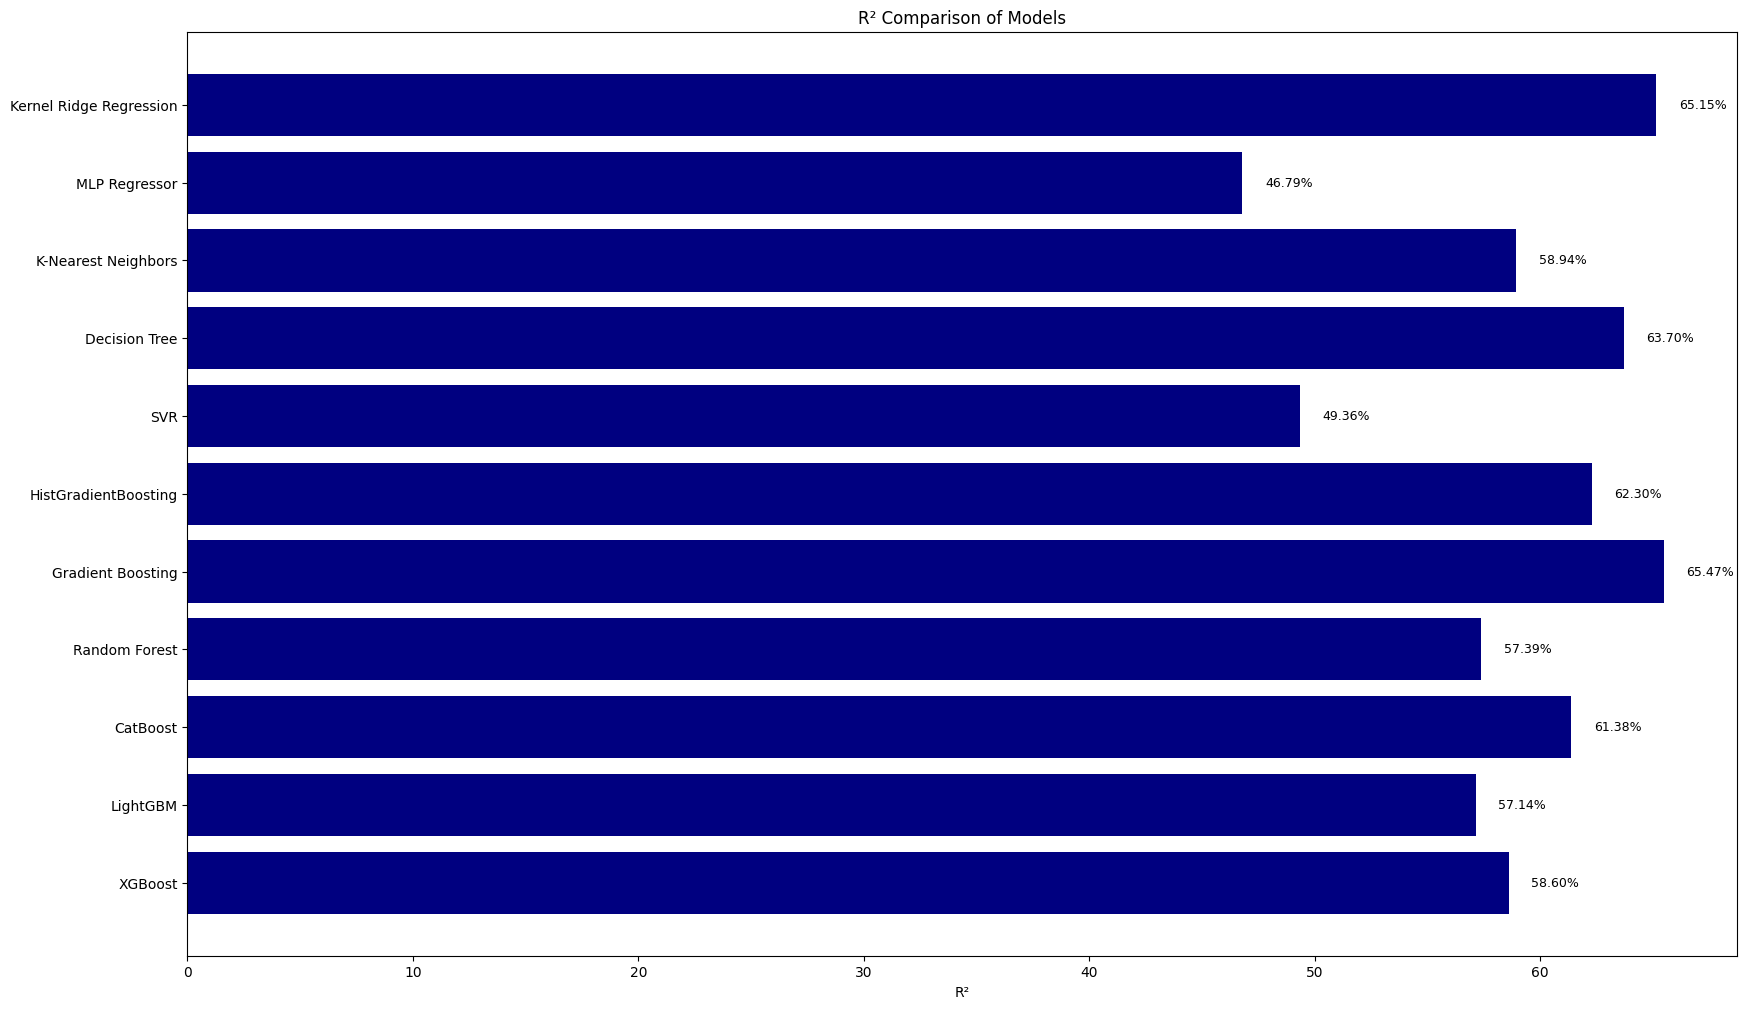

In [75]:
# Set the figure size
plt.figure(figsize=(20, 12))

# Plot R² for all models
plt.barh(results_df['Model'], results_df['R²'], color='navy')
plt.xlabel('R²')
plt.title('R² Comparison of Models')

# Display the values on top of the bars
for index, value in enumerate(results_df['R²']):
    plt.text(value + 1, index, f'{value:.2f}%', va='center', fontsize=9)

plt.show()

In [76]:
from itertools import combinations
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import VotingRegressor
from sklearn.model_selection import train_test_split

In [77]:
# Initialize models with the best parameters you provided
models_dict = {
    'XGBoost': XGBRegressor(n_estimators=115, learning_rate=0.0428, max_depth=3,
                            subsample=0.859, colsample_bytree=0.974, gamma=0.818, min_child_weight=4),
    'LightGBM': LGBMRegressor(n_estimators=252, learning_rate=0.085, num_leaves=25,
                              min_child_samples=10, subsample=0.996),
    'CatBoost': CatBoostRegressor(iterations=218, learning_rate=0.036, depth=5),
    'Random Forest': RandomForestRegressor(n_estimators=226, max_depth=3, min_samples_split=3, min_samples_leaf=1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=62, max_depth=3, min_samples_split=4, min_samples_leaf=3),
    'HistGradientBoosting': HistGradientBoostingRegressor(learning_rate=0.0356, max_iter=148, max_depth=4, min_samples_leaf=3),
    'SVR': SVR(C=2.0, epsilon=0.279, kernel='poly'),
    'Decision Tree': DecisionTreeRegressor(max_depth=4, min_samples_split=7, min_samples_leaf=4),
    'K-Nearest Neighbors': KNeighborsRegressor(n_neighbors=6, weights='distance', p=1),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=147, learning_rate_init=0.0387, alpha=0.003, max_iter=438),
    'Kernel Ridge Regression': KernelRidge(alpha=0.0132, kernel='rbf')
}

In [78]:
# Initialize lists to store the results
combinations_results = []

In [ ]:
from itertools import combinations
from sklearn.ensemble import VotingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, median_absolute_error, r2_score
import joblib  # For saving the best model

# Initialize a list to store results
combinations_results = []

# Initialize variables to track the best model
best_r2 = -float('inf')
best_model = None
best_combination = None

# Loop through all combinations of 3 models
for model_combination in combinations(models_dict.keys(), 3):
    try:
        # Extract the models from the dictionary
        selected_models = [(model, models_dict[model]) for model in model_combination]

        # Debug: Print the current combination
        print(f"Training combination: {' + '.join(model_combination)}")

        # Create the voting model with the selected models
        voting_model = VotingRegressor(estimators=selected_models)

        # Fit the voting model
        voting_model.fit(X_train_scaled, y_train)

        # Make predictions on the test set
        y_pred = voting_model.predict(X_test_scaled)

        # Evaluate the performance
        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        medae = median_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        # Debug: Print evaluation metrics
        print(f"Metrics for {' + '.join(model_combination)}:")
        print(f"  MSE: {mse:.4f}")
        print(f"  MAE: {mae:.4f}")
        print(f"  MedAE: {medae:.4f}")
        print(f"  R²: {r2:.4f}")
        print("-" * 40)

        # Store the results
        combinations_results.append({
            'Combination': ' + '.join(model_combination),
            'MSE': mse,
            'MAE': mae,
            'MedAE': medae,
            'R2': r2
        })

        # Check if this is the best model
        if r2 > best_r2:
            best_r2 = r2
            best_model = voting_model
            best_combination = model_combination

            # Debug: Print the new best combination
            print(f"New best combination: {' + '.join(model_combination)} with R² = {r2:.4f}")
            print("-" * 40)

    except Exception as e:
        print(f"Error with combination {model_combination}: {e}")

# Save the best model to a .pkl file
if best_model is not None:
    joblib.dump(best_model, 'best_voting_model.pkl')
    print(f"Best model saved as 'best_voting_model.pkl' with combination: {' + '.join(best_combination)}")
else:
    print("No valid model found to save.")

# Print or analyze the results
print("\nAll Combinations Results:")
for result in combinations_results:
    print(result)

Training combination: XGBoost + LightGBM + CatBoost
Error with combination ('XGBoost', 'LightGBM', 'CatBoost'): 'super' object has no attribute '__sklearn_tags__'
Training combination: XGBoost + LightGBM + Random Forest
Error with combination ('XGBoost', 'LightGBM', 'Random Forest'): 'super' object has no attribute '__sklearn_tags__'
Training combination: XGBoost + LightGBM + Gradient Boosting
Error with combination ('XGBoost', 'LightGBM', 'Gradient Boosting'): 'super' object has no attribute '__sklearn_tags__'
Training combination: XGBoost + LightGBM + HistGradientBoosting
Error with combination ('XGBoost', 'LightGBM', 'HistGradientBoosting'): 'super' object has no attribute '__sklearn_tags__'
Training combination: XGBoost + LightGBM + SVR
Error with combination ('XGBoost', 'LightGBM', 'SVR'): 'super' object has no attribute '__sklearn_tags__'
Training combination: XGBoost + LightGBM + Decision Tree
Error with combination ('XGBoost', 'LightGBM', 'Decision Tree'): 'super' object has no

d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_

Metrics for LightGBM + CatBoost + Random Forest:
  MSE: 4.3815
  MAE: 1.3391
  MedAE: 0.9715
  R²: 0.6193
----------------------------------------
New best combination: LightGBM + CatBoost + Random Forest with R² = 0.6193
----------------------------------------
Training combination: LightGBM + CatBoost + Gradient Boosting
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000020 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 90
[LightGBM] [Info] Number of data points in the train set: 104, number of used features: 3
[LightGBM] [Info] Start training from score 7.306538
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Metrics for LightGBM + CatBoost + HistGradientBoosting:
  MSE: 4.3142
  MAE: 1.3042
  MedAE: 0.9248
  R²: 0.6251
----------------------------------------
Training combination: LightGBM + CatBoost + SVR
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000022 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 90
[LightGBM] [Info] Number of data points in the train set: 104, number of used features: 3
[LightGBM] [Info] Start training from score 7.306538
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] 

...

d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (438) reached and the optimization hasn't converged yet.
  warnings.warn(


Metrics for Gradient Boosting + SVR + MLP Regressor:
  MSE: 4.0715
  MAE: 1.3244
  MedAE: 0.8397
  R²: 0.6462
----------------------------------------
Training combination: Gradient Boosting + SVR + Kernel Ridge Regression
Metrics for Gradient Boosting + SVR + Kernel Ridge Regression:
  MSE: 3.9010
  MAE: 1.2676
  MedAE: 0.9661
  R²: 0.6610
----------------------------------------
Training combination: Gradient Boosting + Decision Tree + K-Nearest Neighbors
Metrics for Gradient Boosting + Decision Tree + K-Nearest Neighbors:
  MSE: 3.9076
  MAE: 1.3222
  MedAE: 0.9002
  R²: 0.6604
----------------------------------------
Training combination: Gradient Boosting + Decision Tree + MLP Regressor
Metrics for Gradient Boosting + Decision Tree + MLP Regressor:
  MSE: 4.1078
  MAE: 1.3105
  MedAE: 0.9953
  R²: 0.6431
----------------------------------------
Training combination: Gradient Boosting + Decision Tree + Kernel Ridge Regression
Metrics for Gradient Boosting + Decision Tree + Kernel R

d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (438) reached and the optimization hasn't converged yet.
  warnings.warn(


Metrics for Decision Tree + MLP Regressor + Kernel Ridge Regression:
  MSE: 3.9712
  MAE: 1.3374
  MedAE: 1.1385
  R²: 0.6549
----------------------------------------
Training combination: K-Nearest Neighbors + MLP Regressor + Kernel Ridge Regression
Metrics for K-Nearest Neighbors + MLP Regressor + Kernel Ridge Regression:
  MSE: 4.3544
  MAE: 1.4074
  MedAE: 1.1427
  R²: 0.6216
----------------------------------------
Best model saved as 'best_voting_model.pkl' with combination: Decision Tree + K-Nearest Neighbors + Kernel Ridge Regression

All Combinations Results:
{'Combination': 'LightGBM + CatBoost + Random Forest', 'MSE': 4.38151865005541, 'MAE': 1.3390627143077793, 'MedAE': 0.9714997587965337, 'R2': 0.6192648096310354}
{'Combination': 'LightGBM + CatBoost + Gradient Boosting', 'MSE': 4.278431007209258, 'MAE': 1.3014464902492358, 'MedAE': 0.8975328952785562, 'R2': 0.6282226839340972}
{'Combination': 'LightGBM + CatBoost + HistGradientBoosting', 'MSE': 4.314197823528822, 'MAE': 1

d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (438) reached and the optimization hasn't converged yet.
  warnings.warn(


In [80]:
# Convert the results to a DataFrame for easier sorting and plotting
import pandas as pd
results_df = pd.DataFrame(combinations_results)

In [81]:
# Sort by R2 (descending)
best_results = results_df.sort_values(by='R2', ascending=False)

In [82]:
# Display the best model
best_combination = best_results.iloc[0]
print("Best combination of models:")
print(best_combination)


Best combination of models:
Combination    Decision Tree + K-Nearest Neighbors + Kernel R...
MSE                                                     3.726067
MAE                                                     1.252289
MedAE                                                   0.966848
R2                                                      0.676221
Name: 117, dtype: object


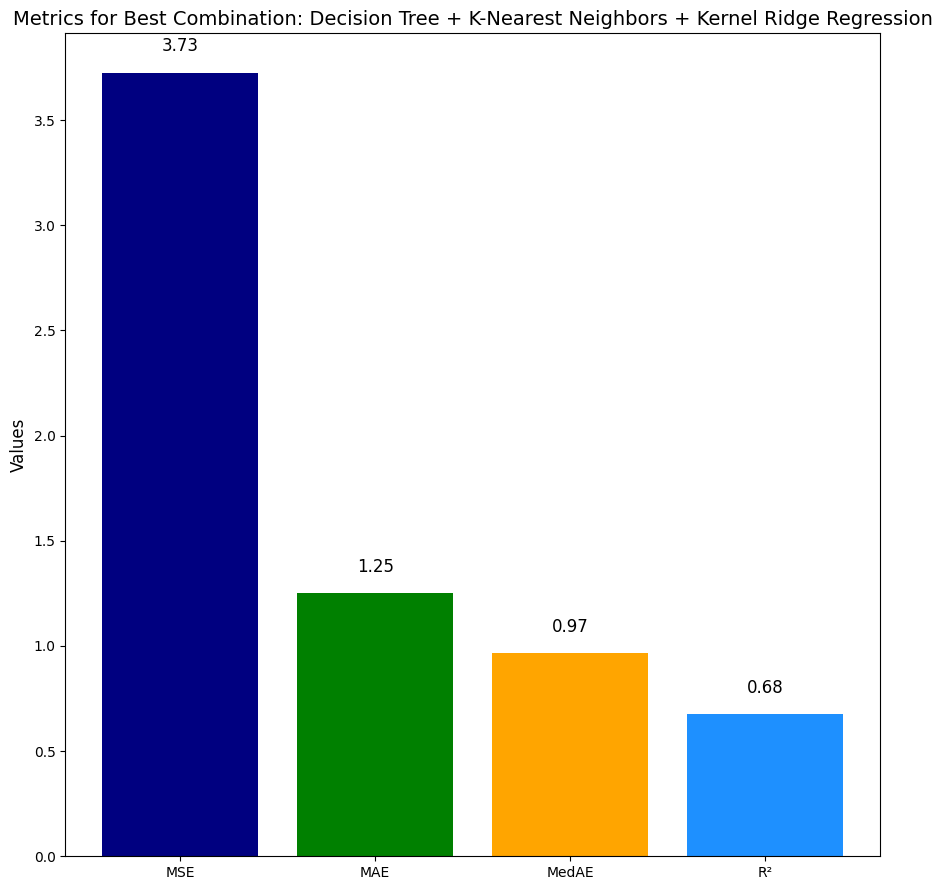

In [83]:
import matplotlib.pyplot as plt

# Data for the best combination
best_combination_name = best_combination['Combination']
metrics = ['MSE', 'MAE', 'MedAE', 'R²']
values = [best_combination['MSE'], best_combination['MAE'], best_combination['MedAE'], best_combination['R2']]

# Plotting the metrics in a single bar chart
fig, ax = plt.subplots(figsize=(9, 9))

# Plot bars for each metric
ax.bar(metrics, values, color=['#000080', '#008000', '#FFA500', '#1E90FF'])

# Adding labels and title
ax.set_title(f'Metrics for Best Combination: {best_combination_name}', fontsize=14)
ax.set_ylabel('Values', fontsize=12)

# Display the values on top of the bars
for i, value in enumerate(values):
    ax.text(i, value + 0.1, f'{value:.2f}', ha='center', fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()

In [84]:
from sklearn.preprocessing import StandardScaler
import joblib

# Create and fit the scaler on the training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Save the scaler to a .pkl file
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [85]:
import joblib
import numpy as np

# Load the saved model and scaler
model = joblib.load('best_voting_model.pkl')
scaler = joblib.load('scaler.pkl')

# Define a function to predict YPP
def predict_ypp(fw, ph, tf):
    """
    Predicts the Yield Per Plant (YPP) for given input features.

    Args:
        fw (float): Fruit Weight
        ph (float): Plant Height
        tf (float): Total Fruits

    Returns:
        float: Predicted YPP value.
    """
    # Create a numpy array from the input features
    input_data = np.array([[fw, ph, tf]])

    # Scale the input data using the same scaler used during training
    input_data_scaled = scaler.transform(input_data)

    # Make a prediction
    prediction = model.predict(input_data_scaled)

    return prediction[0]

# Example usage
fw = 8.3  # Fruit Weight
ph = 89.82  # Plant Height
tf = 21.96  # Total Fruits

# Predict YPP
predicted_ypp = predict_ypp(fw, ph, tf)
print(f"Predicted YPP: {predicted_ypp:.2f}")

Predicted YPP: 10.50


d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Augmentation

In [110]:
data1

,Genotypes,Abbreviate form,DFF,FD,FL,FW,NDVI,PH,SLA,SPAD,TF,YPP,Gid
0,AC‐285,G1,109.07,61.34,6.13,9.93,0.51,108.82,132.40,46.75,15.21,7.83,1
1,BARI‐1,G2,99.32,40.97,4.10,8.30,0.48,89.82,121.08,45.59,21.96,11.13,2
2,BARI‐10,G3,95.32,38.47,3.85,9.50,0.60,103.82,119.16,62.32,14.96,5.72,3
3,BARI‐4,G4,98.32,44.96,4.50,8.00,0.58,93.82,159.86,63.09,29.96,14.54,4
4,BARI‐5,G5,93.82,57.79,5.78,8.20,0.56,94.07,111.21,39.09,13.71,7.67,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,SU‐234,G126,97.07,61.56,6.16,5.99,0.53,109.32,178.61,52.17,12.96,6.89,126
126,SU‐235,G127,97.07,40.50,4.05,4.87,0.58,114.32,132.18,44.45,12.96,7.73,127
127,SU‐38,G128,109.82,62.47,6.25,8.98,0.57,104.57,107.35,38.55,12.21,7.04,128
128,SU‐39,G129,91.82,70.50,7.05,7.46,0.58,100.57,86.12,47.21,18.21,9.22,129


In [111]:
df = data1[['FW', 'PH', 'TF', 'YPP']]
df

,FW,PH,TF,YPP
0,9.93,108.82,15.21,7.83
1,8.30,89.82,21.96,11.13
2,9.50,103.82,14.96,5.72
3,8.00,93.82,29.96,14.54
4,8.20,94.07,13.71,7.67
...,...,...,...,...
125,5.99,109.32,12.96,6.89
126,4.87,114.32,12.96,7.73
127,8.98,104.57,12.21,7.04
128,7.46,100.57,18.21,9.22


In [112]:
# Separate features and target
X = df[['FW', 'PH', 'TF']]  # Features
y = df['YPP']  # Target

# Display the shapes
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (130, 3)
Target shape: (130,)


In [113]:
# Step 3: Data Augmentation with Noise Injection
# Add Gaussian noise to the features
noise = np.random.normal(0, 0.1, size=X.shape)  # Adjust the noise level (0.1) as needed
X_noisy = X + noise

# Duplicate the target variable for the augmented data
y_noisy = y.copy()

# Combine original and augmented data
augmented_data = pd.DataFrame(X_noisy, columns=X.columns)
augmented_data['YPP'] = y_noisy.values

# Merge original and augmented data
final_dataset = pd.concat([df, augmented_data], ignore_index=True)

In [114]:
# Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(final_dataset[['FW', 'PH', 'TF']], final_dataset['YPP'], test_size=0.2, random_state=42)


In [115]:
import optuna
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.neural_network import MLPRegressor

In [116]:
# Define models and their parameters
models = {
    "XGBoost": XGBRegressor,
    "LightGBM": LGBMRegressor,
    "CatBoost": CatBoostRegressor,
    "Random Forest": RandomForestRegressor,
    "Gradient Boosting": GradientBoostingRegressor,
    "HistGradientBoosting": HistGradientBoostingRegressor,
    "Support Vector Regression (SVR)": SVR,
    "Decision Tree": DecisionTreeRegressor,
    "K-Nearest Neighbors": KNeighborsRegressor,
    "MLP Regressor": MLPRegressor,
    "Kernel Ridge Regression": KernelRidge,
}

In [117]:
# Optimization space for each model
def get_model_params(model_name, trial):
    if model_name == "XGBoost":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 50, 300),
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "gamma": trial.suggest_float("gamma", 0, 1),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        }
    elif model_name == "LightGBM":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 50, 300),
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 10, 100),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 30),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        }
    elif model_name == "CatBoost":
        return {
            "iterations": trial.suggest_int("iterations", 50, 300),
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
            "depth": trial.suggest_int("depth", 3, 10),
        }
    elif model_name in ["Random Forest", "Gradient Boosting"]:
        return {
            "n_estimators": trial.suggest_int("n_estimators", 50, 300),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
        }
    elif model_name == "HistGradientBoosting":
        return {
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
            "max_iter": trial.suggest_int("max_iter", 50, 300),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
        }
    elif model_name == "Support Vector Regression (SVR)":
        return {
            "C": trial.suggest_float("C", 1e-3, 10, log=True),
            "epsilon": trial.suggest_float("epsilon", 0.01, 1.0),
            "kernel": trial.suggest_categorical("kernel", ["linear", "rbf", "poly"]),
        }
    elif model_name == "Decision Tree":
        return {
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
        }
    elif model_name == "K-Nearest Neighbors":
        return {
            "n_neighbors": trial.suggest_int("n_neighbors", 3, 15),
            "weights": trial.suggest_categorical("weights", ["uniform", "distance"]),
            "p": trial.suggest_int("p", 1, 2),
        }
    elif model_name == "MLP Regressor":
        return {
            "hidden_layer_sizes": trial.suggest_int("hidden_layer_sizes", 50, 200),
            "learning_rate_init": trial.suggest_float("learning_rate_init", 1e-3, 0.1, log=True),
            "alpha": trial.suggest_float("alpha", 1e-3, 10.0, log=True),
            "max_iter": trial.suggest_int("max_iter", 200, 500),
        }
    elif model_name == "Kernel Ridge Regression":
        return {
            "alpha": trial.suggest_float("alpha", 1e-3, 10.0, log=True),
            "kernel": trial.suggest_categorical("kernel", ["linear", "rbf", "poly"]),
        }


In [118]:
# Optimization function
def objective(trial, model_name, X_train, X_test, y_train, y_test):
    model_class = models[model_name]
    params = get_model_params(model_name, trial)
    model = model_class(**params)
    if model_name == "CatBoost":
        model.set_params(silent=True)  # Suppress output for CatBoost

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    return mse

In [119]:
# Tune all models
best_params = {}
for model_name in models.keys():
    print(f"Tuning {model_name}...")
    study = optuna.create_study(direction="minimize")
    study.optimize(lambda trial: objective(trial, model_name, X_train_scaled, X_test_scaled, y_train, y_test), n_trials=50)
    best_params[model_name] = study.best_params
    print(f"Best parameters for {model_name}: {study.best_params}")
    print(f"Best MSE for {model_name}: {study.best_value:.4f}\n")

[I 2025-01-25 18:51:04,537] A new study created in memory with name: no-name-3ff5cda0-deaf-4bd9-a6c8-9e314a6869b2
[I 2025-01-25 18:51:04,607] Trial 0 finished with value: 1.1030069630727555 and parameters: {'n_estimators': 195, 'learning_rate': 0.06785152172302808, 'max_depth': 6, 'subsample': 0.528458931581538, 'colsample_bytree': 0.8370761856442788, 'gamma': 0.13442794527500423, 'min_child_weight': 8}. Best is trial 0 with value: 1.1030069630727555.
[I 2025-01-25 18:51:04,692] Trial 1 finished with value: 3.049116596352497 and parameters: {'n_estimators': 285, 'learning_rate': 0.006665011475297811, 'max_depth': 5, 'subsample': 0.6520994402910911, 'colsample_bytree': 0.5663360267520614, 'gamma': 0.5055863841955078, 'min_child_weight': 6}. Best is trial 0 with value: 1.1030069630727555.


Tuning XGBoost...


[I 2025-01-25 18:51:04,720] Trial 2 finished with value: 4.75703586189887 and parameters: {'n_estimators': 62, 'learning_rate': 0.005435684668508128, 'max_depth': 9, 'subsample': 0.5371698368532042, 'colsample_bytree': 0.755395193229154, 'gamma': 0.14134593686969, 'min_child_weight': 9}. Best is trial 0 with value: 1.1030069630727555.
[I 2025-01-25 18:51:04,761] Trial 3 finished with value: 2.055030971560102 and parameters: {'n_estimators': 156, 'learning_rate': 0.08186834812242533, 'max_depth': 3, 'subsample': 0.798891417668762, 'colsample_bytree': 0.6460483011036771, 'gamma': 0.12460534155304448, 'min_child_weight': 2}. Best is trial 0 with value: 1.1030069630727555.
[I 2025-01-25 18:51:04,818] Trial 4 finished with value: 3.4490308984609546 and parameters: {'n_estimators': 165, 'learning_rate': 0.004118284091811838, 'max_depth': 5, 'subsample': 0.8270239366209755, 'colsample_bytree': 0.8312289576344424, 'gamma': 0.4988963015316672, 'min_child_weight': 5}. Best is trial 0 with value:

Best parameters for XGBoost: {'n_estimators': 297, 'learning_rate': 0.02967635236799368, 'max_depth': 7, 'subsample': 0.6697103111571744, 'colsample_bytree': 0.8687802844576007, 'gamma': 0.2125949791360064, 'min_child_weight': 2}
Best MSE for XGBoost: 0.7406

Tuning LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000025 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 187
[LightGBM] [Info] Number of data points in the train set: 208, number of used features: 3
[LightGBM] [Info] Start training from score 7.138462
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
[I 2025-01-25 18:51:10,317] Trial 5 finished with value: 5.604245195006097 and parameters: {'n_estimators': 231, 'learning_rate': 0.0011985923335529449, 'num_leaves': 72, 'min_child_samples': 29, 'subsample': 0.988311350753972}. Best is trial 1 with value: 1.7597988875267139.
d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\utils\deprecation.py:1

...

Best parameters for K-Nearest Neighbors: {'n_neighbors': 12, 'weights': 'distance', 'p': 1}
Best MSE for K-Nearest Neighbors: 0.6997

Tuning MLP Regressor...


d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (483) reached and the optimization hasn't converged yet.
  warnings.warn(
[I 2025-01-25 18:52:22,982] Trial 2 finished with value: 2.802248061755778 and parameters: {'hidden_layer_sizes': 101, 'learning_rate_init': 0.0012556078133815003, 'alpha': 0.010471295012676615, 'max_iter': 483}. Best is trial 2 with value: 2.802248061755778.
[I 2025-01-25 18:52:23,041] Trial 3 finished with value: 4.307717502189845 and parameters: {'hidden_layer_sizes': 52, 'learning_rate_init': 0.0545748180169057, 'alpha': 0.047628825717708954, 'max_iter': 200}. Best is trial 2 with value: 2.802248061755778.
[I 2025-01-25 18:52:23,098] Trial 4 finished with value: 2.762170892286819 and parameters: {'hidden_layer_sizes': 150, 'learning_rate_init': 0.0381085319231128, 'alpha': 1.0249560571894092, 'max_iter': 441}. Best is trial 4 with value: 2.

Best parameters for MLP Regressor: {'hidden_layer_sizes': 158, 'learning_rate_init': 0.004956247587313851, 'alpha': 0.0038926905376987053, 'max_iter': 228}
Best MSE for MLP Regressor: 1.7337

Tuning Kernel Ridge Regression...


[I 2025-01-25 18:52:31,579] Trial 29 finished with value: 52.64873925897742 and parameters: {'alpha': 0.0016229008833494208, 'kernel': 'linear'}. Best is trial 24 with value: 1.6243043537364519.
[I 2025-01-25 18:52:31,586] Trial 30 finished with value: 1.6530815076207253 and parameters: {'alpha': 0.015724096012817126, 'kernel': 'rbf'}. Best is trial 24 with value: 1.6243043537364519.
[I 2025-01-25 18:52:31,594] Trial 31 finished with value: 1.6243061458463388 and parameters: {'alpha': 0.00107964759573398, 'kernel': 'rbf'}. Best is trial 24 with value: 1.6243043537364519.
[I 2025-01-25 18:52:31,601] Trial 32 finished with value: 1.6339601047976502 and parameters: {'alpha': 0.0073566896169930665, 'kernel': 'rbf'}. Best is trial 24 with value: 1.6243043537364519.
[I 2025-01-25 18:52:31,609] Trial 33 finished with value: 1.6267783176762771 and parameters: {'alpha': 0.003065615382574806, 'kernel': 'rbf'}. Best is trial 24 with value: 1.6243043537364519.
[I 2025-01-25 18:52:31,617] Trial 34 

Best parameters for Kernel Ridge Regression: {'alpha': 0.001115614146965339, 'kernel': 'rbf'}
Best MSE for Kernel Ridge Regression: 1.6243



In [120]:
# Save best parameters for all models
print("Best parameters for all models:")
for model, params in best_params.items():
    print(f"{model}: {params}")

Best parameters for all models:
XGBoost: {'n_estimators': 297, 'learning_rate': 0.02967635236799368, 'max_depth': 7, 'subsample': 0.6697103111571744, 'colsample_bytree': 0.8687802844576007, 'gamma': 0.2125949791360064, 'min_child_weight': 2}
LightGBM: {'n_estimators': 291, 'learning_rate': 0.07176699949267416, 'num_leaves': 88, 'min_child_samples': 5, 'subsample': 0.6688506953986836}
CatBoost: {'iterations': 175, 'learning_rate': 0.09912706978703224, 'depth': 10}
Random Forest: {'n_estimators': 88, 'max_depth': 10, 'min_samples_split': 3, 'min_samples_leaf': 1}
Gradient Boosting: {'n_estimators': 208, 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 2}
HistGradientBoosting: {'learning_rate': 0.027927531311194922, 'max_iter': 193, 'max_depth': 8, 'min_samples_leaf': 1}
Support Vector Regression (SVR): {'C': 6.332121904057817, 'epsilon': 0.5766885513230691, 'kernel': 'rbf'}
Decision Tree: {'max_depth': 10, 'min_samples_split': 3, 'min_samples_leaf': 1}
K-Nearest Neighbors: {'

In [121]:
# Initialize a dictionary to store all the models using the best parameters
models = {}

In [122]:
for model_name, params in best_params.items():
    # Initialize each model based on the name and best parameters
    if model_name == 'XGBoost':
        models[model_name] = XGBRegressor(**params)
    elif model_name == 'Support Vector Regression (SVR)':
        models[model_name] = SVR(**params)
    elif model_name == 'K-Nearest Neighbors':
        models[model_name] = KNeighborsRegressor(**params)
    elif model_name == 'Decision Tree':
        models[model_name] = DecisionTreeRegressor(**params)
    elif model_name == 'Random Forest':
        models[model_name] = RandomForestRegressor(**params)
    elif model_name == 'Gradient Boosting':
        models[model_name] = GradientBoostingRegressor(**params)
    elif model_name == 'HistGradientBoosting':
        models[model_name] = HistGradientBoostingRegressor(**params)
    elif model_name == 'CatBoost':
        models[model_name] = CatBoostRegressor(**params)
    elif model_name == 'LightGBM':
        models[model_name] = LGBMRegressor(**params)
    elif model_name == 'Kernel Ridge Regression':
        models[model_name] = KernelRidge(**params)
    elif model_name == 'MLP Regressor':
        models[model_name] = MLPRegressor(**params)
# Print the models to check if all were initialized correctly
print(f"Initialized models: {models.keys()}")

Initialized models: dict_keys(['XGBoost', 'LightGBM', 'CatBoost', 'Random Forest', 'Gradient Boosting', 'HistGradientBoosting', 'Support Vector Regression (SVR)', 'Decision Tree', 'K-Nearest Neighbors', 'MLP Regressor', 'Kernel Ridge Regression'])


In [123]:
# Store the results
results = {}

In [124]:
# Train each model and evaluate performance
for model_name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train)

    # Make predictions
    y_pred = model.predict(X_test_scaled)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    medae = median_absolute_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Store the results
    results[model_name] = {
        'MSE': mse,
        'MedAE': medae,
        'MAE': mae,
        'R2': r2
    }

d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000030 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 187
[LightGBM] [Info] Number of data points in the train set: 208, number of used features: 3
[LightGBM] [Info] Start training from score 7.138462
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

In [125]:
for model_name, metrics in results.items():
    print(f"{model_name} - MSE: {metrics['MSE']:.2f}, MedAE: {metrics['MedAE']:.2f}, MAE: {metrics['MAE']:.2f}, R²: {metrics['R2']*100:.2f}%")

XGBoost - MSE: 0.74, MedAE: 0.55, MAE: 0.66, R²: 87.93%
LightGBM - MSE: 0.54, MedAE: 0.27, MAE: 0.48, R²: 91.25%
CatBoost - MSE: 0.57, MedAE: 0.34, MAE: 0.53, R²: 90.68%
Random Forest - MSE: 0.80, MedAE: 0.54, MAE: 0.70, R²: 86.98%
Gradient Boosting - MSE: 0.27, MedAE: 0.16, MAE: 0.31, R²: 95.53%
HistGradientBoosting - MSE: 0.32, MedAE: 0.27, MAE: 0.40, R²: 94.83%
Support Vector Regression (SVR) - MSE: 1.37, MedAE: 0.61, MAE: 0.85, R²: 77.70%
Decision Tree - MSE: 0.90, MedAE: 0.37, MAE: 0.64, R²: 85.35%
K-Nearest Neighbors - MSE: 0.70, MedAE: 0.58, MAE: 0.64, R²: 88.59%
MLP Regressor - MSE: 2.15, MedAE: 1.04, MAE: 1.22, R²: 65.01%
Kernel Ridge Regression - MSE: 1.62, MedAE: 0.69, MAE: 0.92, R²: 73.52%


In [126]:
import matplotlib.pyplot as plt

In [127]:
# Create a DataFrame from the updated results
results_df = pd.DataFrame([
    {"Model": "XGBoost", "MSE": 0.74, "MedAE": 0.55, "MAE": 0.66, "R²": 87.93},
    {"Model": "LightGBM", "MSE": 0.54, "MedAE": 0.27, "MAE": 0.48, "R²": 91.25},
    {"Model": "CatBoost", "MSE": 0.57, "MedAE": 0.34, "MAE": 0.53, "R²": 90.68},
    {"Model": "Random Forest", "MSE": 0.80, "MedAE": 0.54, "MAE": 0.70, "R²": 86.98},
    {"Model": "Gradient Boosting", "MSE": 0.27, "MedAE": 0.16, "MAE": 0.31, "R²": 95.53},
    {"Model": "HistGradientBoosting", "MSE": 0.32, "MedAE": 0.27, "MAE": 0.40, "R²": 94.83},
    {"Model": "SVR", "MSE": 1.37, "MedAE": 0.61, "MAE": 0.85, "R²": 77.70},
    {"Model": "Decision Tree", "MSE": 0.90, "MedAE": 0.37, "MAE": 0.64, "R²": 85.35},
    {"Model": "K-Nearest Neighbors", "MSE": 0.70, "MedAE": 0.58, "MAE": 0.64, "R²": 88.59},
    {"Model": "MLP Regressor", "MSE": 2.15, "MedAE": 1.04, "MAE": 1.22, "R²": 65.01},
    {"Model": "Kernel Ridge Regression", "MSE": 1.62, "MedAE": 0.69, "MAE": 0.92, "R²": 73.52}
])

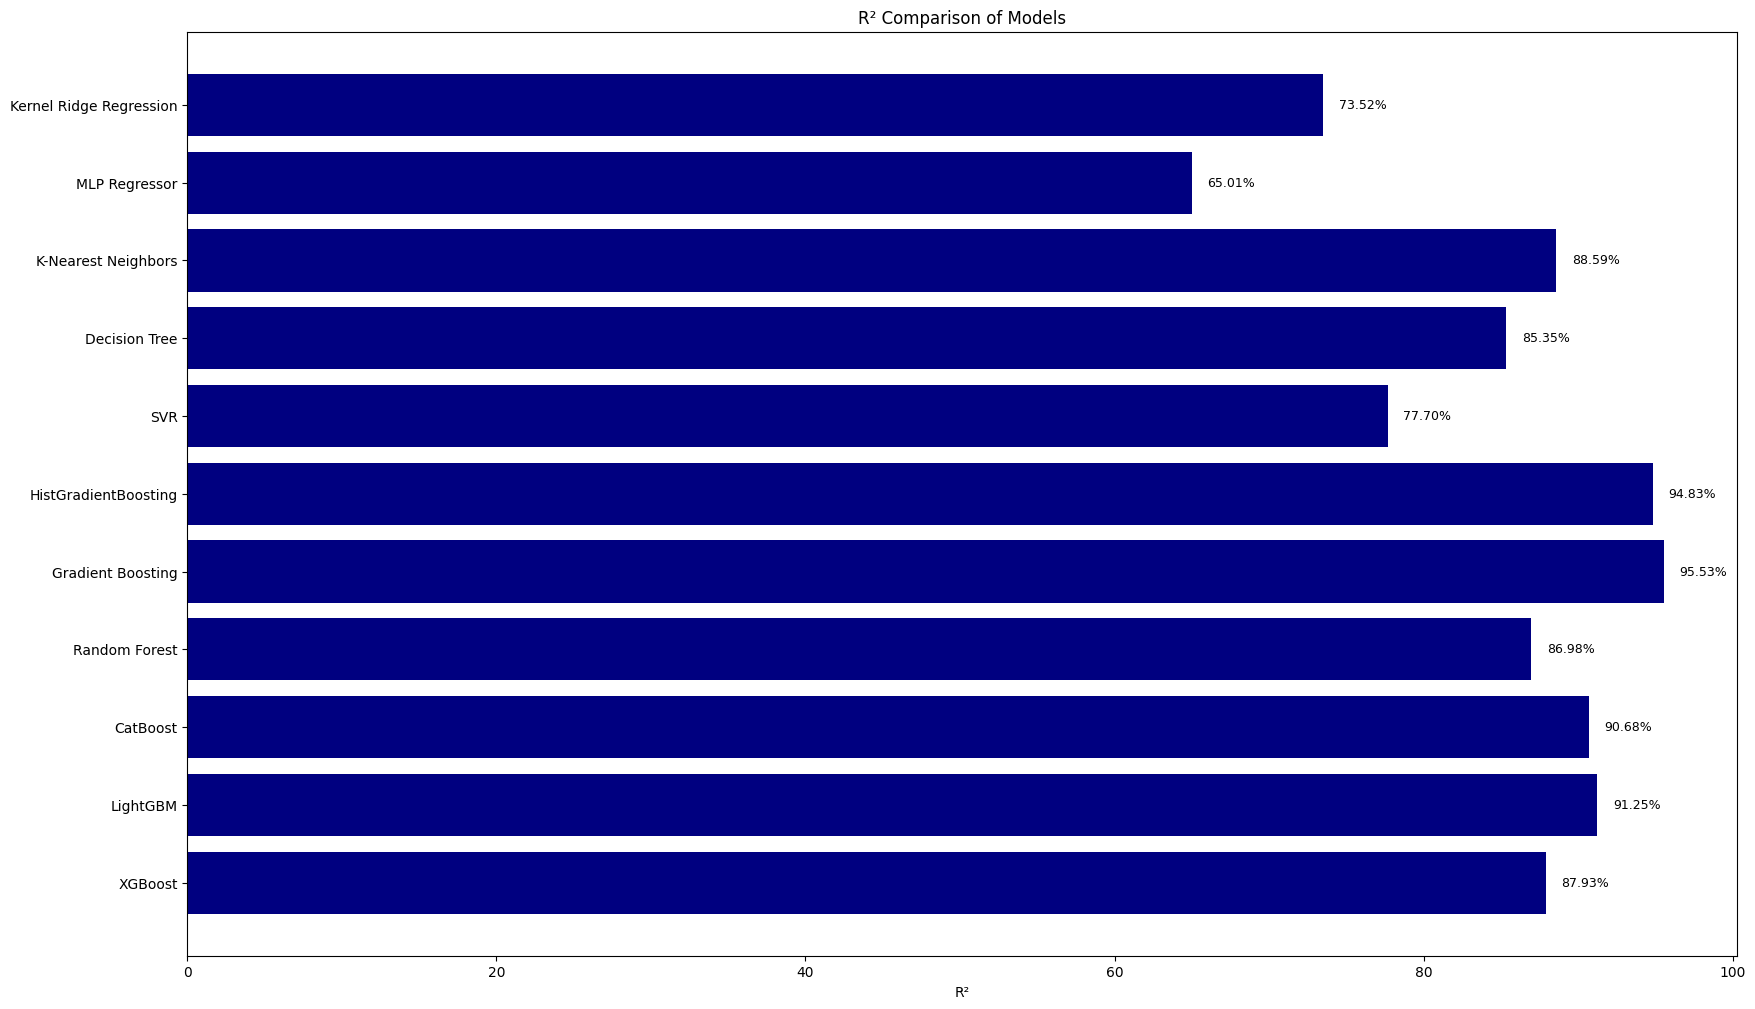

In [128]:
# Set the figure size
plt.figure(figsize=(20, 12))

# Plot R² for all models
plt.barh(results_df['Model'], results_df['R²'], color='navy')
plt.xlabel('R²')
plt.title('R² Comparison of Models')

# Display the values on top of the bars
for index, value in enumerate(results_df['R²']):
    plt.text(value + 1, index, f'{value:.2f}%', va='center', fontsize=9)

plt.show()

   Model   MSE  MedAE   MAE     R²
0    XGB  0.74   0.55  0.66  87.93
1   LGBM  0.54   0.27  0.48  91.25
2   CatB  0.57   0.34  0.53  90.68
3     RF  0.80   0.54  0.70  86.98
4     GB  0.27   0.16  0.31  95.53
5    HGB  0.32   0.27  0.40  94.83
6    SVR  1.37   0.61  0.85  77.70
7     DT  0.90   0.37  0.64  85.35
8    KNN  0.70   0.58  0.64  88.59
9    MLP  2.15   1.04  1.22  65.01
10   KRR  1.62   0.69  0.92  73.52


C:\Users\USER\AppData\Local\Temp\ipykernel_16488\1064108025.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="MSE", data=results_df, palette="viridis")
C:\Users\USER\AppData\Local\Temp\ipykernel_16488\1064108025.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="MAE", data=results_df, palette="viridis")
C:\Users\USER\AppData\Local\Temp\ipykernel_16488\1064108025.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="MedAE", data=results_df, palette="viridis")
C:\Users\USER\AppData\Local\Temp\ipyke

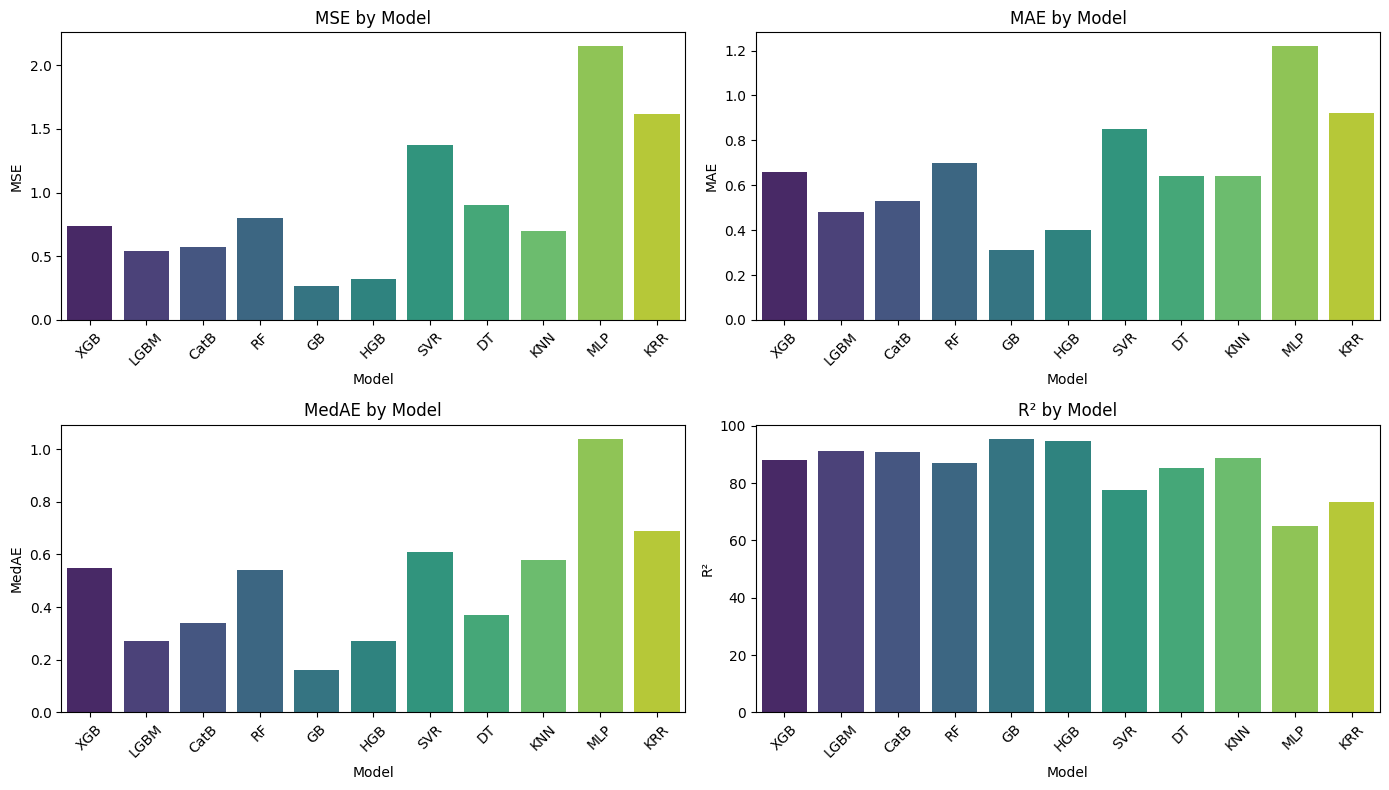

In [130]:
# Define short forms for the model names
model_short_forms = {
    "XGBoost": "XGB",
    "LightGBM": "LGBM",
    "CatBoost": "CatB",
    "Random Forest": "RF",
    "Gradient Boosting": "GB",
    "HistGradientBoosting": "HGB",
    "SVR": "SVR",
    "Decision Tree": "DT",
    "K-Nearest Neighbors": "KNN",
    "MLP Regressor": "MLP",
    "Kernel Ridge Regression": "KRR"
}

# Replace full model names with short forms
results_df["Model"] = results_df["Model"].map(model_short_forms)

# Display the DataFrame
print(results_df)

# Plotting the results
plt.figure(figsize=(14, 8))

# Plot for MSE
plt.subplot(2, 2, 1)
sns.barplot(x="Model", y="MSE", data=results_df, palette="viridis")
plt.title("MSE by Model")
plt.xticks(rotation=45)

# Plot for MAE
plt.subplot(2, 2, 2)
sns.barplot(x="Model", y="MAE", data=results_df, palette="viridis")
plt.title("MAE by Model")
plt.xticks(rotation=45)

# Plot for MedAE
plt.subplot(2, 2, 3)
sns.barplot(x="Model", y="MedAE", data=results_df, palette="viridis")
plt.title("MedAE by Model")
plt.xticks(rotation=45)

# Plot for R²
plt.subplot(2, 2, 4)
sns.barplot(x="Model", y="R²", data=results_df, palette="viridis")
plt.title("R² by Model")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [131]:
models

{'XGBoost': XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8687802844576007, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, gamma=0.2125949791360064,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.02967635236799368,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=2, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=297, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...),
 'LightGBM': LGBMRegressor(learning_rate=0.07176699949267416, min_child_samples=5,
               n_estimators=291, num_leaves=88, subsample=0.6688506953986836),
 'CatBoost': <catb

In [133]:
from itertools import combinations
from sklearn.ensemble import VotingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, median_absolute_error, r2_score
import joblib  # For saving the best model

# Initialize a list to store results
combinations_results = []

# Initialize variables to track the best model
best_r2 = -float('inf')
best_model = None
best_combination = None

# Loop through all combinations of 3 models
for model_combination in combinations(models.keys(), 3):
    try:
        # Extract the models from the dictionary with their best parameters
        selected_models = [(model, models[model]) for model in model_combination]

        # Debug: Print the current combination
        print(f"Training combination: {' + '.join(model_combination)}")

        # Create the voting model with the selected models
        voting_model = VotingRegressor(estimators=selected_models)

        # Fit the voting model on scaled X_train and original y_train
        voting_model.fit(X_train_scaled, y_train)

        # Make predictions on the scaled X_test
        y_pred = voting_model.predict(X_test_scaled)

        # Evaluate the performance
        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        medae = median_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        # Debug: Print evaluation metrics
        print(f"Metrics for {' + '.join(model_combination)}:")
        print(f"  MSE: {mse:.4f}")
        print(f"  MAE: {mae:.4f}")
        print(f"  MedAE: {medae:.4f}")
        print(f"  R²: {r2:.4f}")
        print("-" * 40)

        # Store the results
        combinations_results.append({
            'Combination': ' + '.join(model_combination),
            'MSE': mse,
            'MAE': mae,
            'MedAE': medae,
            'R2': r2
        })

        # Check if this is the best model
        if r2 > best_r2:
            best_r2 = r2
            best_model = voting_model
            best_combination = model_combination

            # Debug: Print the new best combination
            print(f"New best combination: {' + '.join(model_combination)} with R² = {r2:.4f}")
            print("-" * 40)

    except Exception as e:
        print(f"Error with combination {model_combination}: {e}")

# Save the best model to a .pkl file
if best_model is not None:
    joblib.dump(best_model, 'best_voting_model.pkl')
    print(f"Best model saved as 'best_voting_model.pkl' with combination: {' + '.join(best_combination)}")
else:
    print("No valid model found to save.")

# Print or analyze the results
print("\nAll Combinations Results:")
for result in combinations_results:
    print(result)

Training combination: XGBoost + LightGBM + CatBoost
Error with combination ('XGBoost', 'LightGBM', 'CatBoost'): 'super' object has no attribute '__sklearn_tags__'
Training combination: XGBoost + LightGBM + Random Forest
Error with combination ('XGBoost', 'LightGBM', 'Random Forest'): 'super' object has no attribute '__sklearn_tags__'
Training combination: XGBoost + LightGBM + Gradient Boosting
Error with combination ('XGBoost', 'LightGBM', 'Gradient Boosting'): 'super' object has no attribute '__sklearn_tags__'
Training combination: XGBoost + LightGBM + HistGradientBoosting
Error with combination ('XGBoost', 'LightGBM', 'HistGradientBoosting'): 'super' object has no attribute '__sklearn_tags__'
Training combination: XGBoost + LightGBM + Support Vector Regression (SVR)
Error with combination ('XGBoost', 'LightGBM', 'Support Vector Regression (SVR)'): 'super' object has no attribute '__sklearn_tags__'
Training combination: XGBoost + LightGBM + Decision Tree
Error with combination ('XGBoo

d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


9:	learn: 2.2549091	total: 64.9ms	remaining: 1.07s
10:	learn: 2.1795937	total: 71.2ms	remaining: 1.06s
11:	learn: 2.1013388	total: 77.9ms	remaining: 1.06s
12:	learn: 2.0430890	total: 84.9ms	remaining: 1.06s
13:	learn: 1.9712714	total: 92ms	remaining: 1.06s
14:	learn: 1.9130819	total: 98.3ms	remaining: 1.05s
15:	learn: 1.8564900	total: 105ms	remaining: 1.04s
16:	learn: 1.7959164	total: 111ms	remaining: 1.03s
17:	learn: 1.7580770	total: 112ms	remaining: 975ms
18:	learn: 1.7052525	total: 118ms	remaining: 972ms
19:	learn: 1.6494047	total: 125ms	remaining: 966ms
20:	learn: 1.6108522	total: 131ms	remaining: 963ms
21:	learn: 1.5589500	total: 138ms	remaining: 957ms
22:	learn: 1.5145347	total: 144ms	remaining: 953ms
23:	learn: 1.4853562	total: 150ms	remaining: 947ms
24:	learn: 1.4441972	total: 157ms	remaining: 942ms
25:	learn: 1.4133772	total: 163ms	remaining: 936ms
26:	learn: 1.3877273	total: 170ms	remaining: 930ms
27:	learn: 1.3475143	total: 176ms	remaining: 923ms
28:	learn: 1.3210988	total: 

d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

...

Metrics for Support Vector Regression (SVR) + Decision Tree + MLP Regressor:
  MSE: 1.0392
  MAE: 0.7996
  MedAE: 0.6647
  R²: 0.8306
----------------------------------------
Training combination: Support Vector Regression (SVR) + Decision Tree + Kernel Ridge Regression
Metrics for Support Vector Regression (SVR) + Decision Tree + Kernel Ridge Regression:
  MSE: 0.8386
  MAE: 0.7337
  MedAE: 0.5996
  R²: 0.8633
----------------------------------------
Training combination: Support Vector Regression (SVR) + K-Nearest Neighbors + MLP Regressor
Metrics for Support Vector Regression (SVR) + K-Nearest Neighbors + MLP Regressor:
  MSE: 1.2003
  MAE: 0.8812
  MedAE: 0.7462
  R²: 0.8043
----------------------------------------
Training combination: Support Vector Regression (SVR) + K-Nearest Neighbors + Kernel Ridge Regression
Metrics for Support Vector Regression (SVR) + K-Nearest Neighbors + Kernel Ridge Regression:
  MSE: 1.0033
  MAE: 0.7559
  MedAE: 0.7148
  R²: 0.8364
-------------------

d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (228) reached and the optimization hasn't converged yet.
  warnings.warn(


Metrics for Support Vector Regression (SVR) + MLP Regressor + Kernel Ridge Regression:
  MSE: 1.4334
  MAE: 0.9345
  MedAE: 0.9022
  R²: 0.7663
----------------------------------------
Training combination: Decision Tree + K-Nearest Neighbors + MLP Regressor
Metrics for Decision Tree + K-Nearest Neighbors + MLP Regressor:
  MSE: 0.7910
  MAE: 0.7374
  MedAE: 0.7515
  R²: 0.8711
----------------------------------------
Training combination: Decision Tree + K-Nearest Neighbors + Kernel Ridge Regression
Metrics for Decision Tree + K-Nearest Neighbors + Kernel Ridge Regression:
  MSE: 0.7011
  MAE: 0.6586
  MedAE: 0.6540
  R²: 0.8857
----------------------------------------
Training combination: Decision Tree + MLP Regressor + Kernel Ridge Regression


d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (228) reached and the optimization hasn't converged yet.
  warnings.warn(


Metrics for Decision Tree + MLP Regressor + Kernel Ridge Regression:
  MSE: 0.9524
  MAE: 0.8036
  MedAE: 0.7366
  R²: 0.8447
----------------------------------------
Training combination: K-Nearest Neighbors + MLP Regressor + Kernel Ridge Regression
Metrics for K-Nearest Neighbors + MLP Regressor + Kernel Ridge Regression:
  MSE: 1.2171
  MAE: 0.8826
  MedAE: 0.8783
  R²: 0.8016
----------------------------------------
Best model saved as 'best_voting_model.pkl' with combination: LightGBM + Gradient Boosting + HistGradientBoosting

All Combinations Results:
{'Combination': 'LightGBM + CatBoost + Random Forest', 'MSE': 0.5234349968796833, 'MAE': 0.5505268665941299, 'MedAE': 0.4483365220160418, 'R2': 0.9146716359207979}
{'Combination': 'LightGBM + CatBoost + Gradient Boosting', 'MSE': 0.3856838573229153, 'MAE': 0.4216133067455597, 'MedAE': 0.24187482983467534, 'R2': 0.937127297958097}
{'Combination': 'LightGBM + CatBoost + HistGradientBoosting', 'MSE': 0.3975725639494666, 'MAE': 0.42619

In [134]:

# Convert the results to a DataFrame for easier sorting and plotting
import pandas as pd
results_df = pd.DataFrame(combinations_results)

In [135]:
# Sort by R2 (descending)
best_results = results_df.sort_values(by='R2', ascending=False)

In [136]:
# Display the best model
best_combination = best_results.iloc[0]
print("Best combination of models:")
print(best_combination)

Best combination of models:
Combination    LightGBM + Gradient Boosting + HistGradientBoo...
MSE                                                     0.285722
MAE                                                     0.360534
MedAE                                                   0.203031
R2                                                      0.953423
Name: 15, dtype: object


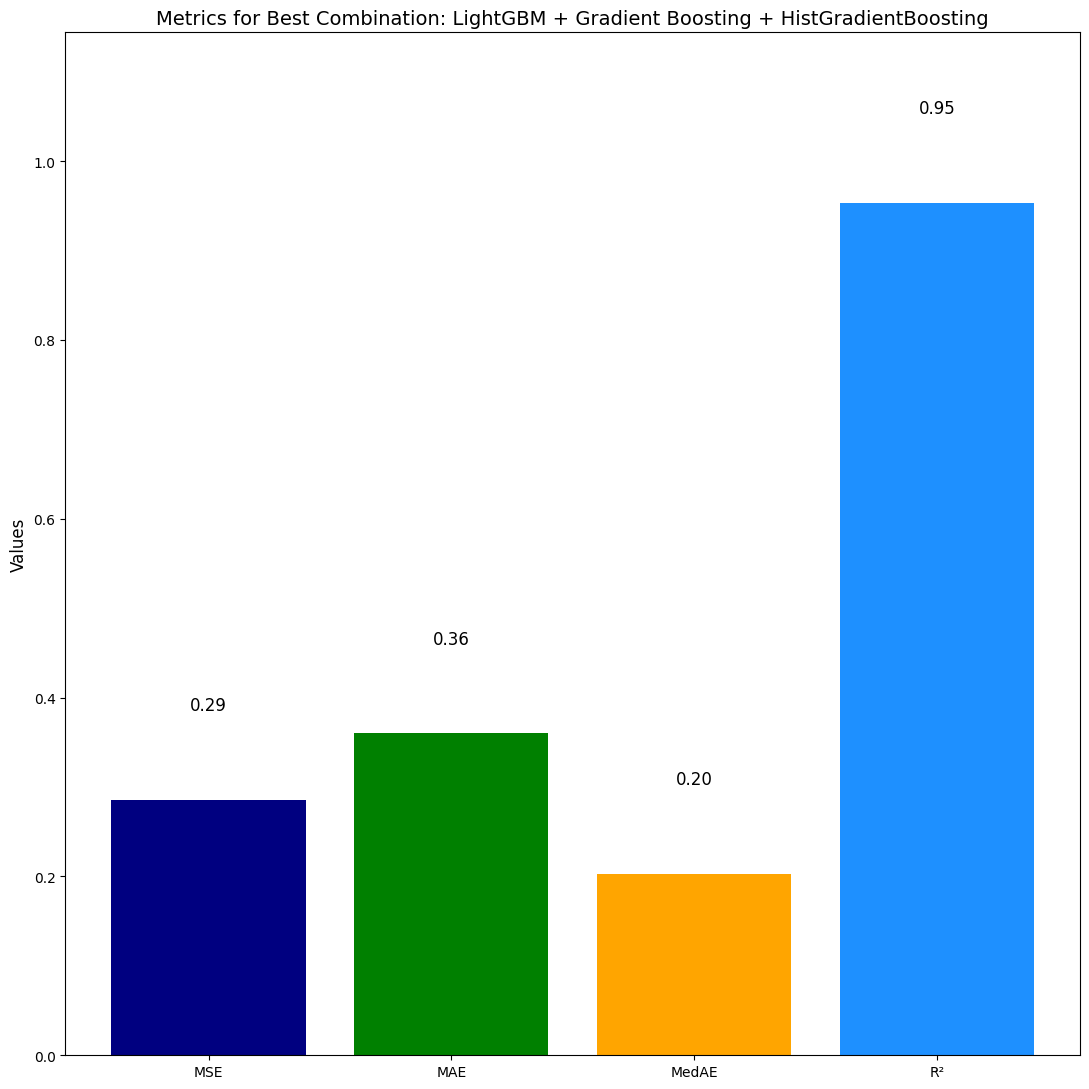

In [139]:
import matplotlib.pyplot as plt

# Data for the best combination
best_combination_name = best_combination['Combination']
metrics = ['MSE', 'MAE', 'MedAE', 'R²']
values = [best_combination['MSE'], best_combination['MAE'], best_combination['MedAE'], best_combination['R2']]

# Plotting the metrics in a single bar chart
fig, ax = plt.subplots(figsize=(11, 11))

# Plot bars for each metric
bars = ax.bar(metrics, values, color=['#000080', '#008000', '#FFA500', '#1E90FF'])

# Adding labels and title
ax.set_title(f'Metrics for Best Combination: {best_combination_name}', fontsize=14)
ax.set_ylabel('Values', fontsize=12)

# Display the values on top of the bars
for bar, value in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.1, f'{value:.2f}', ha='center', fontsize=12)

# Adjust y-axis limits to ensure all bars fit
ax.set_ylim(0, max(values) * 1.2)  # Increase the upper limit by 20% of the maximum value

# Show the plot
plt.tight_layout()
plt.show()

In [141]:

from sklearn.preprocessing import StandardScaler
import joblib

# Create and fit the new scaler on the training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Overwrite the existing scaler file
joblib.dump(scaler, 'scaler.pkl')

print("Scaler has been overwritten and saved to 'scaler.pkl'.")

Scaler has been overwritten and saved to 'scaler.pkl'.


In [142]:

import joblib
import numpy as np

# Load the saved model and scaler
model = joblib.load('best_voting_model.pkl')
scaler = joblib.load('scaler.pkl')

# Define a function to predict YPP
def predict_ypp(fw, ph, tf):
    """
    Predicts the Yield Per Plant (YPP) for given input features.

    Args:
        fw (float): Fruit Weight
        ph (float): Plant Height
        tf (float): Total Fruits

    Returns:
        float: Predicted YPP value.
    """
    # Create a numpy array from the input features
    input_data = np.array([[fw, ph, tf]])

    # Scale the input data using the same scaler used during training
    input_data_scaled = scaler.transform(input_data)

    # Make a prediction
    prediction = model.predict(input_data_scaled)

    return prediction[0]

# Example usage
fw = 8.3  # Fruit Weight
ph = 89.82  # Plant Height
tf = 21.96  # Total Fruits

# Predict YPP
predicted_ypp = predict_ypp(fw, ph, tf)
print(f"Predicted YPP: {predicted_ypp:.2f}")

Predicted YPP: 11.12


d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Hamim\Eggplant Voting Ensemble\venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [148]:
import pandas as pd

# Existing results DataFrame
results_df = pd.DataFrame([
    {"Model": "XGBoost", "MSE": 0.74, "MedAE": 0.55, "MAE": 0.66, "R²": 87.93},
    {"Model": "LightGBM", "MSE": 0.54, "MedAE": 0.27, "MAE": 0.48, "R²": 91.25},
    {"Model": "CatBoost", "MSE": 0.57, "MedAE": 0.34, "MAE": 0.53, "R²": 90.68},
    {"Model": "Random Forest", "MSE": 0.80, "MedAE": 0.54, "MAE": 0.70, "R²": 86.98},
    {"Model": "Gradient Boosting", "MSE": 0.27, "MedAE": 0.16, "MAE": 0.31, "R²": 95.53},
    {"Model": "HistGradientBoosting", "MSE": 0.32, "MedAE": 0.27, "MAE": 0.40, "R²": 94.83},
    {"Model": "SVR", "MSE": 1.37, "MedAE": 0.61, "MAE": 0.85, "R²": 77.70},
    {"Model": "Decision Tree", "MSE": 0.90, "MedAE": 0.37, "MAE": 0.64, "R²": 85.35},
    {"Model": "K-Nearest Neighbors", "MSE": 0.70, "MedAE": 0.58, "MAE": 0.64, "R²": 88.59},
    {"Model": "MLP Regressor", "MSE": 2.15, "MedAE": 1.04, "MAE": 1.22, "R²": 65.01},
    {"Model": "Kernel Ridge Regression", "MSE": 1.62, "MedAE": 0.69, "MAE": 0.92, "R²": 73.52}
])

# Best model results with the name "Voting Ensemble Model"
best_model_results = {
    "Model": "Voting Ensemble Model",  # Name of the best model
    "MSE": 0.285722,
    "MedAE": 0.203031,
    "MAE": 0.360534,
    "R²": 0.953423 * 100  # Convert R² to percentage for consistency
}

# Convert the dictionary to a DataFrame
best_model_df = pd.DataFrame([best_model_results])

# Append the best model results to the existing results_df using pd.concat
results_df = pd.concat([results_df, best_model_df], ignore_index=True)

# Display the updated results_df
print("Updated Results DataFrame:")
print(results_df)

# Sort by R² to compare models (descending order)
results_df_sorted = results_df.sort_values(by="R²", ascending=False)
print("\nSorted Results by R²:")
print(results_df_sorted)

Updated Results DataFrame:
                      Model       MSE     MedAE       MAE       R²
0                   XGBoost  0.740000  0.550000  0.660000  87.9300
1                  LightGBM  0.540000  0.270000  0.480000  91.2500
2                  CatBoost  0.570000  0.340000  0.530000  90.6800
3             Random Forest  0.800000  0.540000  0.700000  86.9800
4         Gradient Boosting  0.270000  0.160000  0.310000  95.5300
5      HistGradientBoosting  0.320000  0.270000  0.400000  94.8300
6                       SVR  1.370000  0.610000  0.850000  77.7000
7             Decision Tree  0.900000  0.370000  0.640000  85.3500
8       K-Nearest Neighbors  0.700000  0.580000  0.640000  88.5900
9             MLP Regressor  2.150000  1.040000  1.220000  65.0100
10  Kernel Ridge Regression  1.620000  0.690000  0.920000  73.5200
11    Voting Ensemble Model  0.285722  0.203031  0.360534  95.3423

Sorted Results by R²:
                      Model       MSE     MedAE       MAE       R²
4         Gr

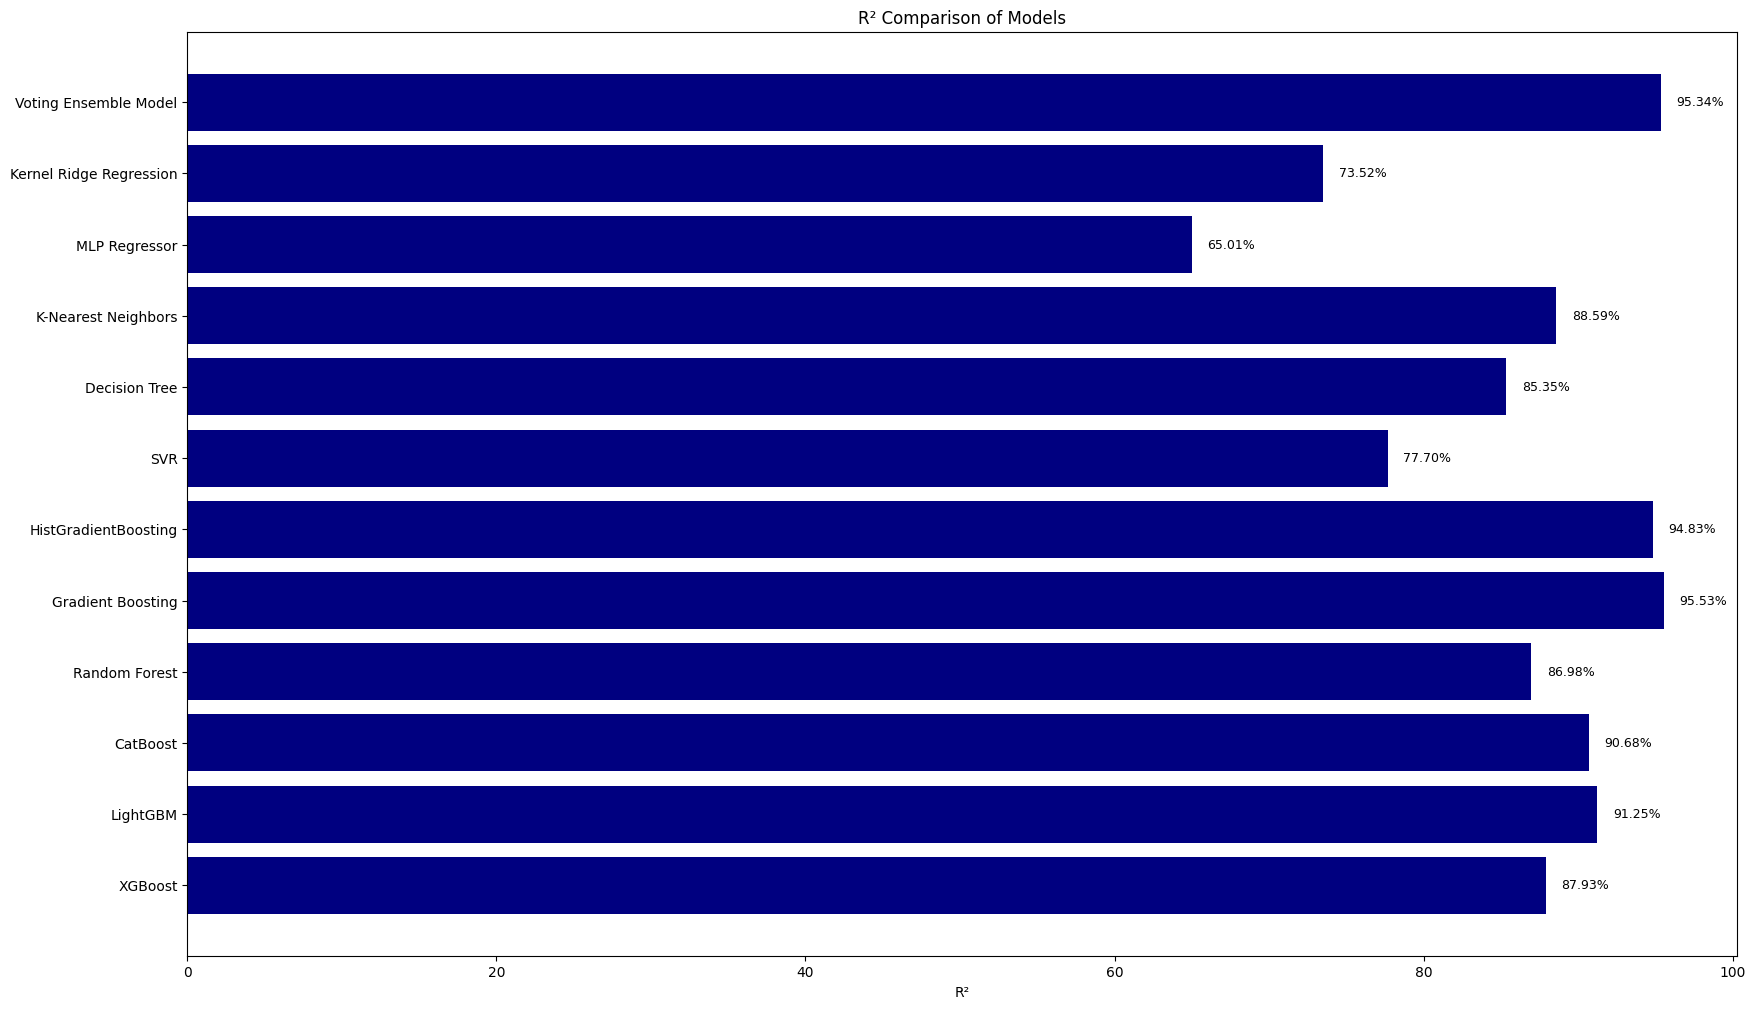

In [149]:
# Set the figure size
plt.figure(figsize=(20, 12))

# Plot R² for all models
plt.barh(results_df['Model'], results_df['R²'], color='navy')
plt.xlabel('R²')
plt.title('R² Comparison of Models')

# Display the values on top of the bars
for index, value in enumerate(results_df['R²']):
    plt.text(value + 1, index, f'{value:.2f}%', va='center', fontsize=9)

plt.show()